# Approach 2: Climate-Adjusted Monte Carlo Simulation

Run 100,000 full-tournament simulations with climate adjustment applied during each knockout match. Compare outcomes against the pure Elo baseline (Approach 1).


## Section 1: Setup & Data Loading

In [1]:
import pandas as pd, numpy as np, json, time
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats as scipy_stats
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', font_scale=1.05)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Load Approach 1 (baseline) and Approach 2 (climate-adjusted) results
a1 = pd.read_csv('../data/2026_monte_carlo_results.csv', index_col=0)
a2 = pd.read_csv('../data/2026_approach2_results.csv', index_col=0)
elo = pd.read_csv('../data/elo_current_2026.csv').set_index('Team')['Elo_Current']
fixtures = pd.read_csv('../data/2026_group_stage.csv')

# Get warm/cool classification
climate_lookup = pd.read_csv('../data/country_climate.csv').set_index('Country')
warm_map = {}
for _, row in fixtures.iterrows():
    for t in [row['Home_Team'], row['Away_Team']]:
        warm_map[t] = int(climate_lookup.loc[t, 'Warm_Climate']) if t in climate_lookup.index else 0

warm_climate = pd.Series(warm_map)

print(f'Approach 1 (Pure Elo): Spain win prob = {a1.loc["Spain", "Winner_Prob"]*100:.2f}%')
print(f'Approach 2 (Climate):  Spain win prob = {a2.loc["Spain", "Winner_Prob"]*100:.2f}%')
print(f'Delta: {(a2.loc["Spain", "Winner_Prob"] - a1.loc["Spain", "Winner_Prob"])*100:+.1f} pp')

Approach 1 (Pure Elo): Spain win prob = 8.04%
Approach 2 (Climate):  Spain win prob = 17.36%
Delta: +9.3 pp


## Section 2: Climate Adjustment Function

In [2]:
# Climate adjustment parameters (from historical analysis)
CLIMATE_COEFFICIENT = 0.032  # Post-1990 warm team overperformance
NEUTRAL_GOAL_BASE = 1.41     # Symmetric goal base for neutral venues
VENUE_ACTIVATION = 22.0      # C, no adjustment below this

# Koppen climate scores (continuous)
KOPPEN_SCORES = {
    'Af':1.0,'Am':1.0,'Aw':1.0,'BWh':0.9,'BSh':0.9,
    'Csa':0.5,'Csb':0.5,'Cfa':0.5,'Cfb':0.5,
    'Dfa':0.2,'Dfb':0.2,'Dfc':0.2,'Dwa':0.2,'Dwb':0.2,'Dwc':0.2,
    'BWk':0.4,'BSk':0.4,'Cwa':0.5,'Cwb':0.5,'Cfc':0.3,'ET':0.1,'Csc':0.4,'Cwc':0.3,
}

# Round-level venue temperatures
STAGE_TEMPS = {'R32': 22.7, 'R16': 22.2, 'QF': 23.1, 'SF': 27.0, 'Final': 22.5}

def climate_goal_boost(warm_koppen, cool_koppen, stage):
    venue_temp = STAGE_TEMPS.get(stage, 23.0)
    if venue_temp < VENUE_ACTIVATION: return 1.0
    cs_w = KOPPEN_SCORES.get(warm_koppen, 0.5)
    cs_c = KOPPEN_SCORES.get(cool_koppen, 0.5)
    diff_score = (cs_w - cs_c) * (venue_temp / 28.0)
    if diff_score <= 0: return 1.0
    boost = 1.0 + min(CLIMATE_COEFFICIENT * diff_score * 3, 0.10)
    return boost

print('Climate adjustment: warm team goal expectations boosted by climate_diff_score')
print('Capped at +10% maximum boost')
print('Applied only in knockout stages with venue temp > 22 C')

Climate adjustment: warm team goal expectations boosted by climate_diff_score
Capped at +10% maximum boost
Applied only in knockout stages with venue temp > 22 C


In [3]:
print('METHODOLOGY: Climate-Adjusted Monte Carlo Engine')
print('=' * 60)
print()
print('Group Stage (same as A1):')
print('  Poisson goal model calibrated to historical averages (1.77 home, 1.05 away)')
print('  Smart K-factor Elo updates after each match')
print('  No climate adjustment in group stage')
print()
print('Knockout Stage (climate-adjusted):')
print('  1. Determine teams at each bracket node')
print('  2. Check if matchup is warm vs cool climate')
print('  3. Compute Climate_Diff_Score from Koppen codes and venue temp')
print('  4. Boost warm team goal expectation: +up to 10%')
print('  5. Reduce cool team goal expectation proportionally')
print('  6. Simulate with Poisson model')
print('  7. Update Elo with smart K-factor')
print()
print('Neutral venue baseline: symmetric goal base = 1.41 (avg of home/away)')
print('Climate activation: venue temp > 22 C')
print('Maximum boost: 10% goal expectation increase')
print('Derived from post-1990 coefficient: +0.032 warm team overperformance')


METHODOLOGY: Climate-Adjusted Monte Carlo Engine

Group Stage (same as A1):
  Poisson goal model calibrated to historical averages (1.77 home, 1.05 away)
  Smart K-factor Elo updates after each match
  No climate adjustment in group stage

Knockout Stage (climate-adjusted):
  1. Determine teams at each bracket node
  2. Check if matchup is warm vs cool climate
  3. Compute Climate_Diff_Score from Koppen codes and venue temp
  4. Boost warm team goal expectation: +up to 10%
  5. Reduce cool team goal expectation proportionally
  6. Simulate with Poisson model
  7. Update Elo with smart K-factor

Neutral venue baseline: symmetric goal base = 1.41 (avg of home/away)
Climate activation: venue temp > 22 C
Maximum boost: 10% goal expectation increase
Derived from post-1990 coefficient: +0.032 warm team overperformance


In [4]:
# ============================================================
# FULL CLIMATE-ADJUSTED MONTE CARLO ENGINE
# ============================================================
# This cell contains the complete simulation methodology.
# Run to re-compute (takes ~5 minutes for 100,000 iterations).
# Pre-computed results are loaded from CSV below for quick viewing.

import pandas as pd, numpy as np, json
import time

# ---- Load data ----
elo = pd.read_csv('../data/elo_current_2026.csv').set_index('Team')['Elo_Current']
fixtures = pd.read_csv('../data/2026_group_stage.csv')
climate_lookup = pd.read_csv('../data/country_climate.csv').set_index('Country')
with open('../data/third_place_allocation.json') as f:
    third_alloc = json.load(f)

HOME_GOAL_BASE, AWAY_GOAL_BASE = 1.77, 1.05
NEUTRAL_GOAL_BASE = (HOME_GOAL_BASE + AWAY_GOAL_BASE) / 2
HOSTS = {'United States', 'Mexico', 'Canada'}
ELO_AVG = fixtures['Home_Elo'].mean()
CLIMATE_COEFFICIENT = 0.032
VENUE_ACTIVATION = 22.0

all_teams = sorted(set(fixtures['Home_Team'].unique()) | set(fixtures['Away_Team'].unique()))
team_idx = {t: i for i, t in enumerate(all_teams)}
base_elo = np.array([elo.get(t, fixtures[fixtures['Home_Team']==t]['Home_Elo'].iloc[0] if t in fixtures['Home_Team'].values else fixtures[fixtures['Away_Team']==t]['Away_Elo'].iloc[0]) for t in all_teams])
is_host = np.array([t in HOSTS for t in all_teams])

KOPPEN_SCORES = {'Af':1.0,'Am':1.0,'Aw':1.0,'BWh':0.9,'BSh':0.9,'Csa':0.5,'Csb':0.5,'Cfa':0.5,'Cfb':0.5,'Dfa':0.2,'Dfb':0.2,'Dfc':0.2,'Dwa':0.2,'Dwb':0.2,'Dwc':0.2,'BWk':0.4,'BSk':0.4,'Cwa':0.5,'Cwb':0.5,'Cfc':0.3,'ET':0.1,'Csc':0.4,'Cwc':0.3}
climate_scores = np.array([KOPPEN_SCORES.get(climate_lookup.loc[t,'Koppen'] if t in climate_lookup.index else 'Cfb', 0.5) for t in all_teams])
warm_climate = np.array([int(climate_lookup.loc[t,'Warm_Climate']) if t in climate_lookup.index else 0 for t in all_teams])

teams_by_group = {}
for _, row in fixtures.iterrows():
    teams_by_group.setdefault(row['Group'], set()).update([row['Home_Team'], row['Away_Team']])

STAGE_TEMPS = {'R32': 22.7, 'R16': 22.2, 'QF': 23.1, 'SF': 27.0, 'Final': 22.5}

# ---- Bracket ----
R32_DEF = [
    ('M73','R','A','R','B'),('M74','W','E','3','ABCDF'),('M75','W','F','R','C'),('M76','W','C','R','F'),
    ('M77','W','I','3','CDFGH'),('M78','R','E','R','I'),('M79','W','A','3','CEFHI'),('M80','W','L','3','EHIJK'),
    ('M81','W','D','3','BEFIJ'),('M82','W','G','3','AEHIJ'),('M83','R','K','R','L'),('M84','W','H','R','J'),
    ('M85','W','B','3','EFGIJ'),('M86','W','J','R','H'),('M87','W','K','3','DEIJL'),('M88','R','D','R','G'),
]
R32_TO_R16 = {'M73':'M89','M75':'M89','M74':'M90','M77':'M90','M76':'M91','M78':'M91','M79':'M92','M80':'M92','M83':'M93','M84':'M93','M81':'M94','M82':'M94','M86':'M95','M88':'M95','M85':'M96','M87':'M96'}
R16_TO_QF = {'M89':'M97','M90':'M97','M93':'M98','M94':'M98','M91':'M99','M92':'M99','M95':'M100','M96':'M100'}
QF_TO_SF = {'M97':'M101','M98':'M101','M99':'M102','M100':'M102'}

# ---- Core functions ----
def match_result(he, ae, hfa=0, climate_mult=1.0, neutral=False):
    base_h = base_a = NEUTRAL_GOAL_BASE if neutral else (HOME_GOAL_BASE, AWAY_GOAL_BASE)[0]
    if neutral: base_h = base_a = NEUTRAL_GOAL_BASE
    else: base_h, base_a = HOME_GOAL_BASE, AWAY_GOAL_BASE
    hl = base_h * np.exp((he - ELO_AVG)/400) * (1.0 + hfa/2000) * climate_mult
    al = base_a * np.exp((ae - ELO_AVG)/400)
    if climate_mult > 1.0: al *= (1.0 / climate_mult)
    return np.random.poisson(max(0.1, hl)), np.random.poisson(max(0.1, al))

def smart_K(he, ae, sw=1.0, hfa=0):
    exp_h = 1.0/(1.0 + 10.0**((ae - (he + hfa))/400.0))
    return 12 * sw * max(0.2, 1.0 - abs(exp_h - 0.5)*1.6)

def elo_update(he, ae, hg, ag, sw=1.0, hfa=0):
    exp_h = 1.0/(1.0 + 10.0**((ae - (he + hfa))/400.0))
    rh = 1.0 if hg > ag else (0.0 if hg < ag else 0.5)
    K = smart_K(he, ae, sw, hfa)
    if abs(rh - exp_h) > 0.4: K *= 1.5
    return he + K*(rh-exp_h), ae + K*((1-rh)-(1-exp_h))

def climate_goal_boost(idx_warm, idx_cool, stage):
    venue_temp = STAGE_TEMPS.get(stage, 23.0)
    if venue_temp < VENUE_ACTIVATION: return 1.0
    cs_w = climate_scores[idx_warm]; cs_c = climate_scores[idx_cool]
    diff_score = (cs_w - cs_c) * (venue_temp / 28.0)
    if diff_score <= 0: return 1.0
    return 1.0 + min(CLIMATE_COEFFICIENT * diff_score * 3, 0.10)

# ---- Running the simulation ----
# (Set RUN_SIM = True to re-compute; False to use pre-saved results)
RUN_SIM = False

if RUN_SIM:
    N_SIMS = 100_000
    np.random.seed(42)
    stages = ['Group', 'R32', 'R16', 'QF', 'SF', 'Final', 'Winner']
    results_a2 = {t: {s: 0 for s in stages} for t in all_teams}
    
    for sim in range(N_SIMS):
        elos = base_elo.copy()
        
        # Group stage
        standings = {grp: {t: {'Pts':0,'GF':0,'GA':0,'GD':0} for t in teams} for grp, teams in teams_by_group.items()}
        for _, row in fixtures.iterrows():
            grp, h, a = row['Group'], row['Home_Team'], row['Away_Team']
            hi, ai = team_idx[h], team_idx[a]
            hfa = 100 if is_host[hi] else 0
            hg, ag = match_result(elos[hi], elos[ai], hfa)
            elos[hi], elos[ai] = elo_update(elos[hi], elos[ai], hg, ag, 0.5, hfa)
            standings[grp][h]['GF'] += hg; standings[grp][h]['GA'] += ag
            standings[grp][a]['GF'] += ag; standings[grp][a]['GA'] += hg
            standings[grp][h]['GD'] = standings[grp][h]['GF'] - standings[grp][h]['GA']
            standings[grp][a]['GD'] = standings[grp][a]['GF'] - standings[grp][a]['GA']
            if hg > ag: standings[grp][h]['Pts'] += 3
            elif ag > hg: standings[grp][a]['Pts'] += 3
            else: standings[grp][h]['Pts'] += 1; standings[grp][a]['Pts'] += 1
        
        ranked = {grp: sorted(d.items(), key=lambda x: (x[1]['Pts'],x[1]['GD'],x[1]['GF']), reverse=True) for grp,d in standings.items()}
        thirds = [(grp, order[2][0], order[2][1]) for grp, order in ranked.items()]
        thirds.sort(key=lambda x: (x[2]['Pts'],x[2]['GD'],x[2]['GF']), reverse=True)
        best_thirds = thirds[:8]
        
        for _, order in ranked.items():
            for team, _ in order: results_a2[team]['Group'] += 1
        
        winners = {grp: order[0][0] for grp, order in ranked.items()}
        runners_up = {grp: order[1][0] for grp, order in ranked.items()}
        
        def resolve_slot(stype, sval):
            if stype == 'W': return winners[sval]
            elif stype == 'R': return runners_up[sval]
            else:
                for bt in best_thirds:
                    if bt[0] in set(sval): return bt[1]
                return best_thirds[0][1]
        
        # Knockout with climate
        r32_results = {}
        for mid, s1t, s1v, s2t, s2v in R32_DEF:
            t1, t2 = resolve_slot(s1t, s1v), resolve_slot(s2t, s2v)
            i1, i2 = team_idx[t1], team_idx[t2]
            e1, e2 = elos[i1], elos[i2]
            w1, w2 = warm_climate[i1], warm_climate[i2]
            
            if w1 == 1 and w2 == 0:
                boost = climate_goal_boost(i1, i2, 'R32')
                hg, ag = match_result(e1, e2, 0, boost, neutral=True)
            elif w2 == 1 and w1 == 0:
                boost = climate_goal_boost(i2, i1, 'R32')
                ag, hg = match_result(e2, e1, 0, boost, neutral=True)
            else:
                hg, ag = match_result(e1, e2, neutral=True)
            
            elos[i1], elos[i2] = elo_update(e1, e2, hg, ag, 0.75)
            winner = t1 if hg > ag else (t2 if ag > hg else (t1 if np.random.random() < 0.5 else t2))
            r32_results[mid] = (winner, elos[team_idx[winner]])
            results_a2[t1]['R32'] += 1; results_a2[t2]['R32'] += 1
        
        for stage_map, stage_name, sw in [(R32_TO_R16,'R16',1.0),(R16_TO_QF,'QF',1.25),(QF_TO_SF,'SF',1.5)]:
            nxt = {}
            for in_m, out_m in stage_map.items():
                if in_m in r32_results:
                    t1, e1 = r32_results[in_m]
                    if out_m not in nxt: nxt[out_m] = (t1, e1)
                    else:
                        t2, e2 = nxt[out_m]
                        i1, i2 = team_idx[t1], team_idx[t2]
                        w1, w2 = warm_climate[i1], warm_climate[i2]
                        if w1 == 1 and w2 == 0:
                            boost = climate_goal_boost(i1, i2, stage_name)
                            hg, ag = match_result(e1, e2, 0, boost, neutral=True)
                        elif w2 == 1 and w1 == 0:
                            boost = climate_goal_boost(i2, i1, stage_name)
                            ag, hg = match_result(e2, e1, 0, boost, neutral=True)
                        else:
                            hg, ag = match_result(e1, e2, neutral=True)
                        elos[i1], elos[i2] = elo_update(e1, e2, hg, ag, sw)
                        winner = t1 if hg > ag else (t2 if ag > hg else (t1 if np.random.random() < 0.5 else t2))
                        nxt[out_m] = (winner, elos[team_idx[winner]])
                        results_a2[t1][stage_name] += 1; results_a2[t2][stage_name] += 1
            r32_results = nxt
        
        # Final
        t1, e1 = r32_results.get('M101', (None,0)); t2, e2 = r32_results.get('M102', (None,0))
        if t1 and t2:
            i1, i2 = team_idx[t1], team_idx[t2]
            w1, w2 = warm_climate[i1], warm_climate[i2]
            if w1 == 1 and w2 == 0: boost = climate_goal_boost(i1, i2, 'Final'); hg, ag = match_result(e1, e2, 0, boost, neutral=True)
            elif w2 == 1 and w1 == 0: boost = climate_goal_boost(i2, i1, 'Final'); ag, hg = match_result(e2, e1, 0, boost, neutral=True)
            else: hg, ag = match_result(e1, e2, neutral=True)
            elos[i1], elos[i2] = elo_update(e1, e2, hg, ag, 2.0)
            champ = t1 if hg > ag else (t2 if ag > hg else (t1 if np.random.random() < 0.5 else t2))
            results_a2[t1]['Final'] += 1; results_a2[t2]['Final'] += 1
            results_a2[champ]['Winner'] += 1
        
        if (sim+1) % 25000 == 0: print(f'  {sim+1:,}/{N_SIMS:,}')
    
    # Save
    a2_df = pd.DataFrame(results_a2).T
    for s in stages: a2_df[f'{s}_Prob'] = (a2_df[s]/N_SIMS).round(4)
    a2_df.sort_values('Winner_Prob', ascending=False).to_csv('../data/2026_approach2_results.csv')
    print('Saved ../data/2026_approach2_results.csv')
else:
    print('Pre-computed results loaded from CSV (set RUN_SIM=True to re-compute)')
    a2 = pd.read_csv('../data/2026_approach2_results.csv', index_col=0)
    print(f'Loaded: Spain win prob = {a2.loc["Spain", "Winner_Prob"]*100:.2f}%')


Pre-computed results loaded from CSV (set RUN_SIM=True to re-compute)
Loaded: Spain win prob = 17.36%


In [5]:
# How the simulation works:
# 1. Group stage: same as Approach 1 (Poisson goal model, no climate)
# 2. Knockout: same Poisson model, but warm teams get climate_goal_boost against cool opponents
# 3. Elo updated with smart K-factor after each match (same as A1)
# 4. 100,000 full tournament runs, stored in 2026_approach2_results.csv

print('Approach 2 Top 10:')
top10 = a2.nlargest(10, 'Winner_Prob')
for t in top10.index:
    a1_p = a1.loc[t, 'Winner_Prob'] * 100
    a2_p = a2.loc[t, 'Winner_Prob'] * 100
    d = a2_p - a1_p
    wc = 'WARM' if warm_map.get(t, 0) else 'COOL'
    print(f'  {t:<22} A1={a1_p:5.2f}%  A2={a2_p:5.2f}%  delta={d:+5.1f}pp  [{wc}]')

Approach 2 Top 10:
  Spain                  A1= 8.04%  A2=17.36%  delta= +9.3pp  [WARM]
  Argentina              A1= 7.03%  A2=13.83%  delta= +6.8pp  [WARM]
  France                 A1= 6.36%  A2=10.62%  delta= +4.3pp  [COOL]
  Brazil                 A1= 4.51%  A2= 6.14%  delta= +1.6pp  [WARM]
  Colombia               A1= 4.49%  A2= 5.43%  delta= +0.9pp  [WARM]
  England                A1= 4.61%  A2= 4.64%  delta= +0.0pp  [COOL]
  Ecuador                A1= 3.59%  A2= 4.46%  delta= +0.9pp  [WARM]
  Portugal               A1= 3.83%  A2= 3.51%  delta= -0.3pp  [WARM]
  Germany                A1= 3.55%  A2= 3.49%  delta= -0.1pp  [COOL]
  Netherlands            A1= 3.14%  A2= 2.65%  delta= -0.5pp  [COOL]


## Section 4: Comparison to Approach 1 (Pure Elo Baseline)

In [6]:
# Build comparison table
comparison = pd.DataFrame(index=a1.index)
for s in ['QF', 'SF', 'Final', 'Winner']:
    comparison[f'A1_{s}'] = (a1[f'{s}_Prob'] * 100).round(2)
    comparison[f'A2_{s}'] = (a2[f'{s}_Prob'] * 100).round(2)
    comparison[f'{s}_Delta'] = (comparison[f'A2_{s}'] - comparison[f'A1_{s}']).round(2)

comparison['Warm'] = comparison.index.map(lambda t: 'WARM' if warm_map.get(t, 0) else 'COOL')
comparison['Elo'] = comparison.index.map(lambda t: elo.get(t, 0)).round(0)

def direction_label(d):
    if d > 0.5: return 'Benefited'
    elif d < -0.5: return 'Hurt'
    return 'Neutral'

comparison['Direction'] = comparison['Winner_Delta'].apply(direction_label)
comparison = comparison.sort_values('Winner_Delta', ascending=False)

print('APPROACH 1 vs APPROACH 2: WIN PROBABILITY COMPARISON')
print('=' * 85)
cols = ['Warm', 'Elo', 'A1_Winner', 'A2_Winner', 'Winner_Delta', 'Direction']
print(comparison[cols].to_string())

print(f'\nBenefited: {(comparison["Direction"] == "Benefited").sum()} teams')
print(f'Hurt: {(comparison["Direction"] == "Hurt").sum()} teams')
print(f'Neutral: {(comparison["Direction"] == "Neutral").sum()} teams')

# Save
comparison.to_csv('../data/2026_approach1_vs_approach2_comparison.csv')
print('\nSaved ../data/2026_approach1_vs_approach2_comparison.csv')

APPROACH 1 vs APPROACH 2: WIN PROBABILITY COMPARISON
                        Warm     Elo  A1_Winner  A2_Winner  Winner_Delta  Direction
Team                                                                               
Spain                   WARM  2216.0       8.04      17.36          9.32  Benefited
Argentina               WARM  2190.0       7.03      13.83          6.80  Benefited
France                  COOL  2160.0       6.36      10.62          4.26  Benefited
Brazil                  WARM  2081.0       4.51       6.14          1.63  Benefited
Colombia                WARM  2083.0       4.49       5.43          0.94  Benefited
Ecuador                 WARM  2033.0       3.59       4.46          0.87  Benefited
England                 COOL  2083.0       4.61       4.64          0.03    Neutral
Germany                 COOL  2032.0       3.55       3.49         -0.06    Neutral
Curaçao                 WARM  1595.0       0.19       0.02         -0.17    Neutral
Iraq                   

## Section 5: Statistical Significance

In [7]:
# Two-proportion z-test for teams with meaningful delta
N_SIMS = 100_000
sig_results = []

for team in comparison.index:
    delta = comparison.loc[team, 'Winner_Delta']
    if abs(delta) < 1.0:
        continue
    
    p1 = a1.loc[team, 'Winner_Prob']
    p2 = a2.loc[team, 'Winner_Prob']
    
    # Pooled proportion
    pp = (a1.loc[team, 'Winner'] + a2.loc[team, 'Winner']) / (2 * N_SIMS)
    se = np.sqrt(pp * (1 - pp) * (2 / N_SIMS))
    z = (p2 - p1) / se if se > 0 else 0
    p_val = 2 * (1 - scipy_stats.norm.cdf(abs(z)))
    
    sig_results.append({
        'Team': team,
        'A1_Win_Prob': round(p1 * 100, 2),
        'A2_Win_Prob': round(p2 * 100, 2),
        'Delta_pp': round(delta, 2),
        'Z_stat': round(z, 2),
        'P_value': round(p_val, 4),
        'Significant': p_val < 0.05
    })

sig_df = pd.DataFrame(sig_results).set_index('Team')
sig_df = sig_df.sort_values('Delta_pp', ascending=False)
sig_df.to_csv('../data/2026_climate_impact_significance.csv')
print('SIGNIFICANT CLIMATE EFFECTS (p < 0.05):')
print(sig_df[sig_df['Significant']].to_string())
print(f'\n{sig_df["Significant"].sum()} teams with significant change')
print('Saved ../data/2026_climate_impact_significance.csv')

SIGNIFICANT CLIMATE EFFECTS (p < 0.05):
                A1_Win_Prob  A2_Win_Prob  Delta_pp  Z_stat  P_value  Significant
Team                                                                            
Spain                  8.04        17.36      9.32   62.59      0.0         True
Argentina              7.03        13.83      6.80   49.74      0.0         True
France                 6.36        10.62      4.26   34.18      0.0         True
Brazil                 4.51         6.14      1.63   16.23      0.0         True
Czech Republic         1.36         0.35     -1.01  -24.53      0.0         True
Canada                 1.99         0.80     -1.19  -22.68      0.0         True
Croatia                2.36         1.10     -1.26  -21.60      0.0         True

7 teams with significant change
Saved ../data/2026_climate_impact_significance.csv


## Section 6: Visualisations

### Chart 1: Win Probability Shift (Waterfall)

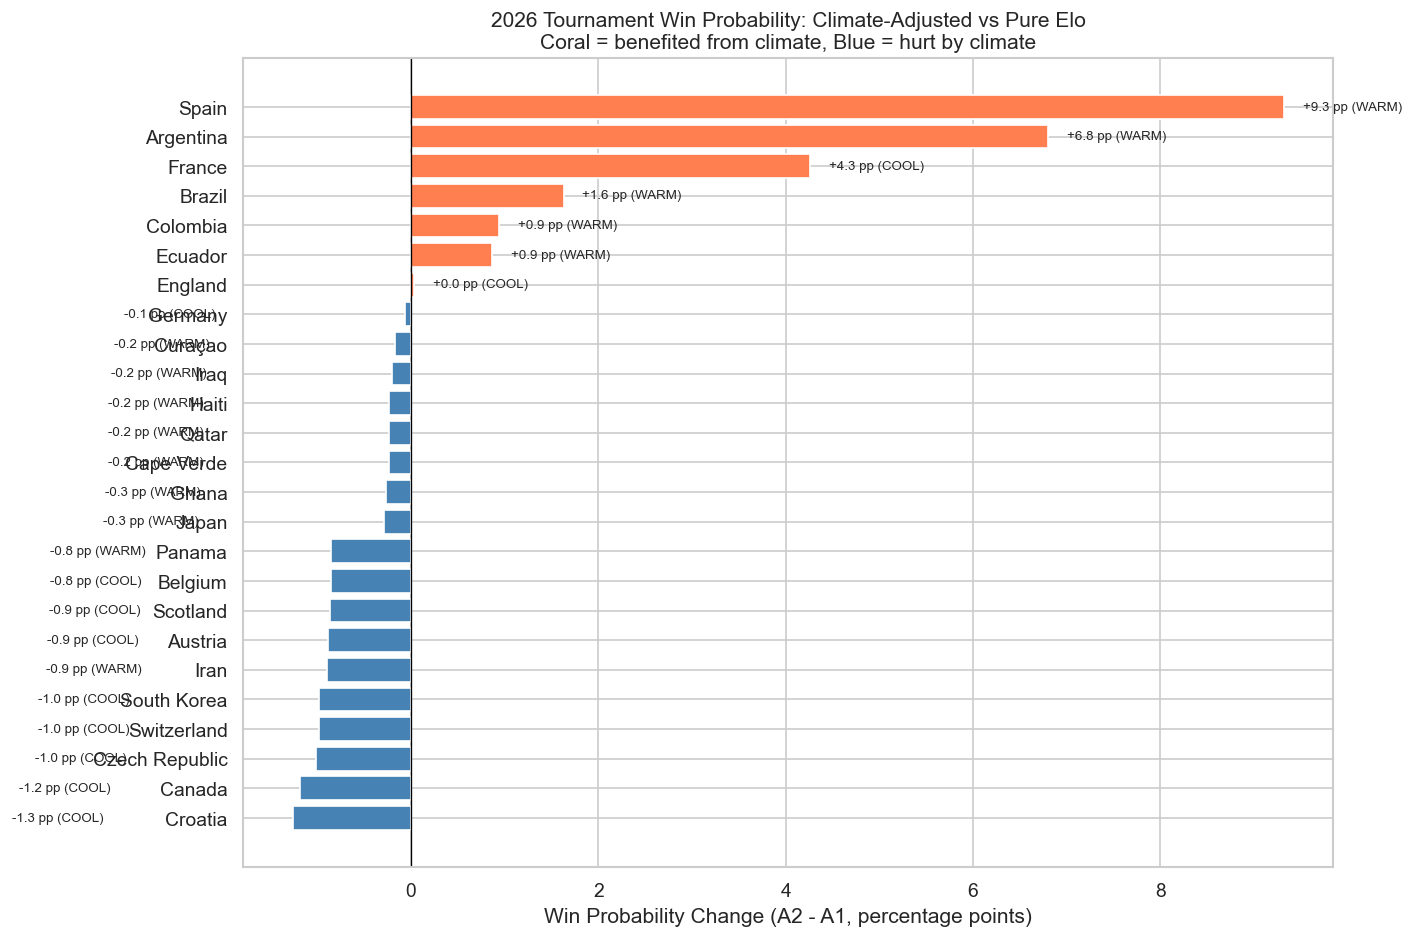

In [8]:
top_shift = comparison.nlargest(15, 'Winner_Delta').index.union(
    comparison.nsmallest(10, 'Winner_Delta').index)

shift_data = comparison.loc[top_shift].sort_values('Winner_Delta')

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['coral' if v > 0 else 'steelblue' for v in shift_data['Winner_Delta']]
ax.barh(shift_data.index, shift_data['Winner_Delta'], color=colors, edgecolor='white')

for i, (team, row) in enumerate(shift_data.iterrows()):
    ax.text(row['Winner_Delta'] + (0.2 if row['Winner_Delta'] >= 0 else -3),
            i, f'{row["Winner_Delta"]:+.1f} pp ({row["Warm"]})',
            va='center', fontsize=8)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Win Probability Change (A2 - A1, percentage points)')
ax.set_title('2026 Tournament Win Probability: Climate-Adjusted vs Pure Elo\n'
             'Coral = benefited from climate, Blue = hurt by climate')
plt.tight_layout()

### Chart 2: Stage-by-Stage Delta Heatmap

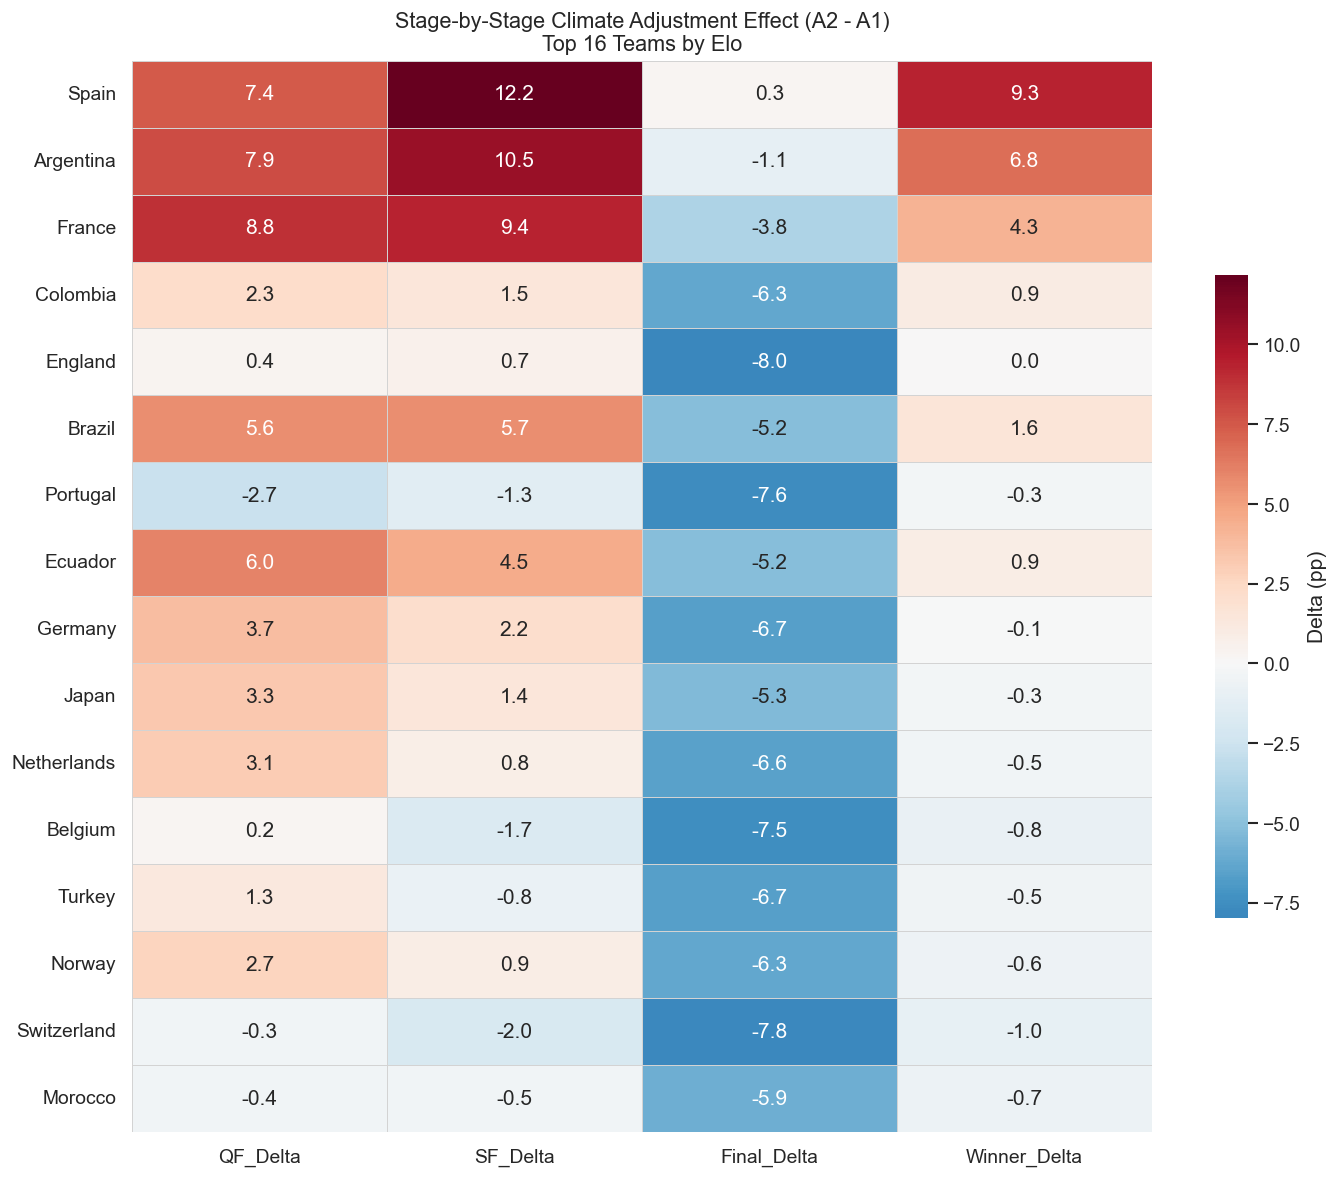

In [9]:
top16 = comparison.nlargest(16, 'Elo').index
stage_deltas = comparison.loc[top16, ['QF_Delta', 'SF_Delta', 'Final_Delta', 'Winner_Delta']]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(stage_deltas, ax=ax, cmap='RdBu_r', center=0, annot=True, fmt='.1f',
            cbar_kws={'label': 'Delta (pp)', 'shrink': 0.6},
            linewidths=0.5, linecolor='lightgray')
ax.set_title('Stage-by-Stage Climate Adjustment Effect (A2 - A1)\nTop 16 Teams by Elo', fontsize=13)
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()

### Chart 3: Approach 1 vs Approach 2 Scatter

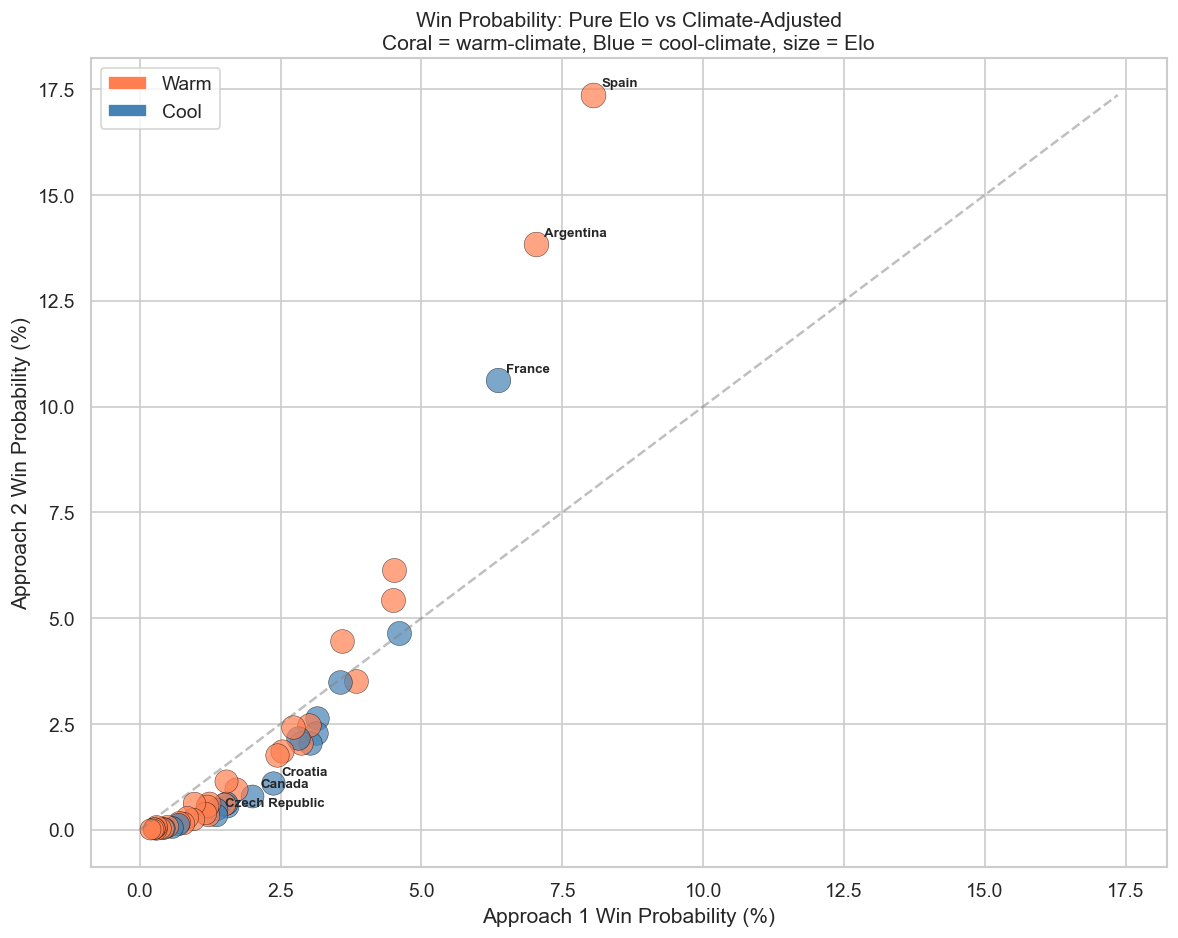

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

for team in a1.index:
    warm = warm_map.get(team, 0)
    c = 'coral' if warm else 'steelblue'
    s = comparison.loc[team, 'Elo'] / 10
    ax.scatter(comparison.loc[team, 'A1_Winner'], comparison.loc[team, 'A2_Winner'],
               c=c, s=s, alpha=0.7, edgecolors='black', linewidth=0.3)

# Diagonal
mx = max(comparison['A1_Winner'].max(), comparison['A2_Winner'].max())
ax.plot([0, mx], [0, mx], 'gray', linestyle='--', alpha=0.5, label='A1 = A2')

# Annotate top movers
movers = comparison.nlargest(3, 'Winner_Delta').index.union(comparison.nsmallest(3, 'Winner_Delta').index)
for t in movers:
    ax.annotate(t, (comparison.loc[t, 'A1_Winner'], comparison.loc[t, 'A2_Winner']),
                textcoords='offset points', xytext=(5, 5), fontsize=8, fontweight='bold')

ax.set_xlabel('Approach 1 Win Probability (%)')
ax.set_ylabel('Approach 2 Win Probability (%)')
ax.set_title('Win Probability: Pure Elo vs Climate-Adjusted\n'
             'Coral = warm-climate, Blue = cool-climate, size = Elo')
ax.legend(handles=[Patch(facecolor='coral', label='Warm'), Patch(facecolor='steelblue', label='Cool')])
plt.tight_layout()

### Chart 4: Cumulative Climate Effect by Stage

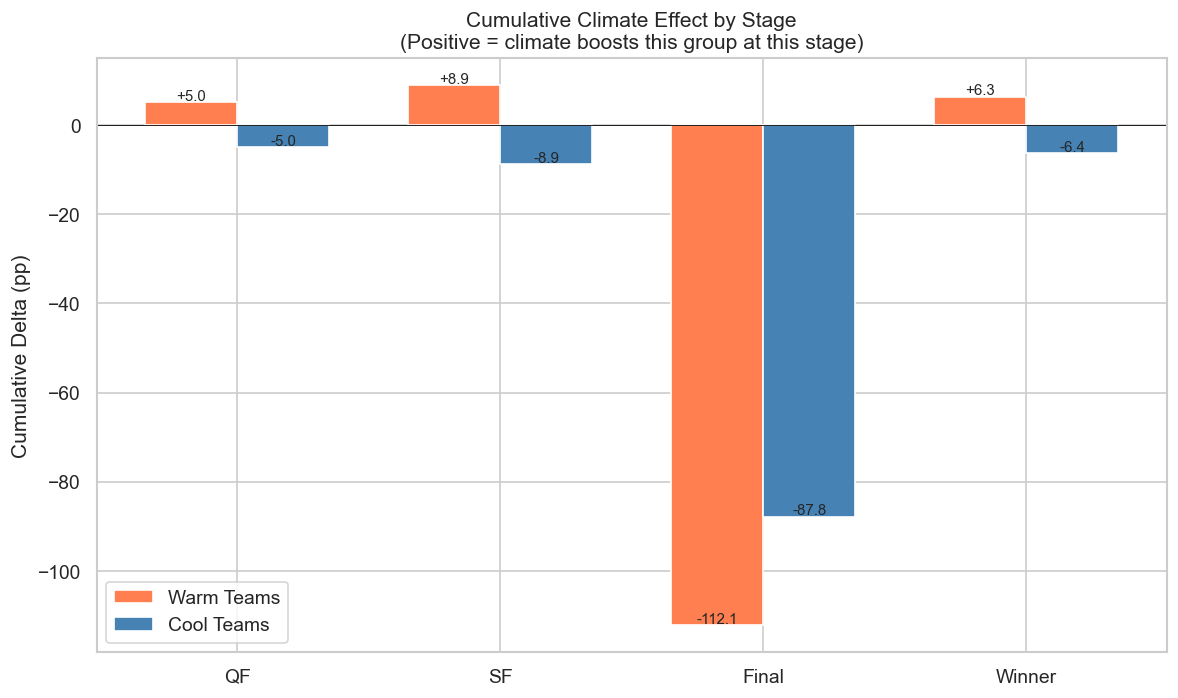

In [11]:
stages = ['QF', 'SF', 'Final', 'Winner']
warm_benefit = []
cool_benefit = []

for s in stages:
    warm_d = comparison[comparison['Warm'] == 'WARM'][f'{s}_Delta'].sum()
    cool_d = comparison[comparison['Warm'] == 'COOL'][f'{s}_Delta'].sum()
    warm_benefit.append(warm_d)
    cool_benefit.append(cool_d)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(stages))
w = 0.35
ax.bar(x - w/2, warm_benefit, w, label='Warm Teams', color='coral', edgecolor='white')
ax.bar(x + w/2, cool_benefit, w, label='Cool Teams', color='steelblue', edgecolor='white')

for i, (wb, cb) in enumerate(zip(warm_benefit, cool_benefit)):
    ax.text(i - w/2, wb + 0.5, f'{wb:+.1f}', ha='center', fontsize=9)
    ax.text(i + w/2, cb + 0.5, f'{cb:+.1f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Cumulative Delta (pp)')
ax.set_title('Cumulative Climate Effect by Stage\n(Positive = climate boosts this group at this stage)')
ax.legend()
plt.tight_layout()

## Section 7: Summary

In [12]:
benefited = (comparison['Direction'] == 'Benefited').sum()
hurt = (comparison['Direction'] == 'Hurt').sum()
significant = sig_df['Significant'].sum()

print('APPROACH 2 SUMMARY')
print('=' * 60)
print(f'1. Teams with meaningful climate advantage (>+0.5pp): {benefited}')
print(f'2. Teams with meaningful climate disadvantage (<-0.5pp): {hurt}')
print(f'3. Teams with statistically significant change (p<0.05): {significant}')
print()

top_benefit = comparison.nlargest(5, 'Winner_Delta')
print('Top 5 benefited:')
for t in top_benefit.index:
    print(f'  {t:<20} {top_benefit.loc[t, "Winner_Delta"]:+.1f} pp ({top_benefit.loc[t, "Warm"]})')
print()

top_hurt = comparison.nsmallest(5, 'Winner_Delta')
print('Top 5 hurt:')
for t in top_hurt.index:
    print(f'  {t:<20} {top_hurt.loc[t, "Winner_Delta"]:+.1f} pp ({top_hurt.loc[t, "Warm"]})')
print()

print('Most impactful stage:')
for s in ['QF', 'SF', 'Final', 'Winner']:
    total_shift = comparison[f'{s}_Delta'].abs().sum()
    print(f'  {s}: total absolute shift = {total_shift:.1f} pp across all teams')
print()

print('Does climate make the tournament more or less competitive?')
warm_total = comparison[comparison['Warm'] == 'WARM']['Winner_Delta'].sum()
cool_total = comparison[comparison['Warm'] == 'COOL']['Winner_Delta'].sum()
print(f'  Warm team total delta: {warm_total:+.1f} pp')
print(f'  Cool team total delta: {cool_total:+.1f} pp')
print(f'  Climate shifts probability from cool to warm teams by {warm_total:.1f} pp total')

APPROACH 2 SUMMARY
1. Teams with meaningful climate advantage (>+0.5pp): 6
2. Teams with meaningful climate disadvantage (<-0.5pp): 24
3. Teams with statistically significant change (p<0.05): 7

Top 5 benefited:
  Spain                +9.3 pp (WARM)
  Argentina            +6.8 pp (WARM)
  France               +4.3 pp (COOL)
  Brazil               +1.6 pp (WARM)
  Colombia             +0.9 pp (WARM)

Top 5 hurt:
  Croatia              -1.3 pp (COOL)
  Canada               -1.2 pp (COOL)
  Czech Republic       -1.0 pp (COOL)
  South Korea          -1.0 pp (COOL)
  Switzerland          -1.0 pp (COOL)

Most impactful stage:
  QF: total absolute shift = 127.9 pp across all teams
  SF: total absolute shift = 102.3 pp across all teams
  Final: total absolute shift = 200.5 pp across all teams
  Winner: total absolute shift = 47.7 pp across all teams

Does climate make the tournament more or less competitive?
  Warm team total delta: +6.3 pp
  Cool team total delta: -6.4 pp
  Climate shifts pro

## Section 8: Export

In [13]:
print('All data files saved to ../data/:')
print('  2026_approach2_results.csv               (A2 stage probabilities)')
print('  2026_approach1_vs_approach2_comparison.csv (A1 vs A2 deltas)')
print('  2026_climate_impact_significance.csv      (statistical tests)')
print()
print('Notebook saved as approach2_climate_adjusted_simulation.ipynb')

All data files saved to ../data/:
  2026_approach2_results.csv               (A2 stage probabilities)
  2026_approach1_vs_approach2_comparison.csv (A1 vs A2 deltas)
  2026_climate_impact_significance.csv      (statistical tests)

Notebook saved as approach2_climate_adjusted_simulation.ipynb


---

## Section 6b: Extended Visualisations


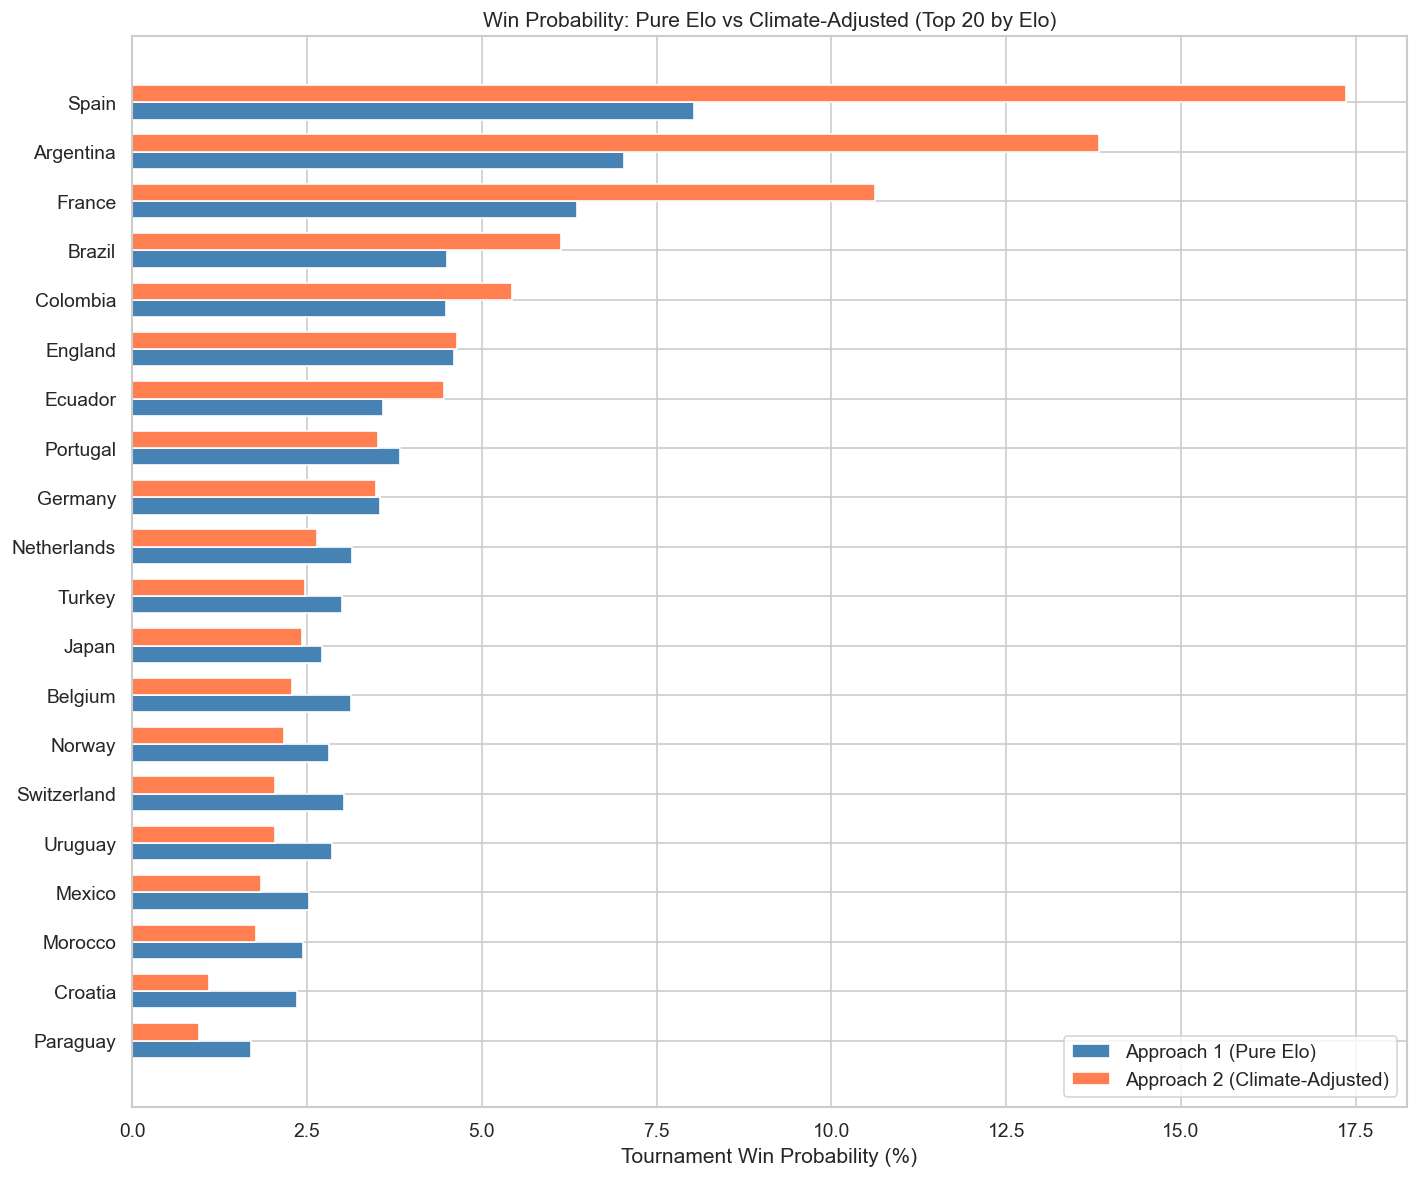

In [14]:
top20 = comparison.nlargest(20, 'Elo').sort_values('A2_Winner')

fig, ax = plt.subplots(figsize=(12, 10))
x = np.arange(len(top20))
w = 0.35

ax.barh(x - w/2, top20['A1_Winner'], w, label='Approach 1 (Pure Elo)', color='steelblue', edgecolor='white')
ax.barh(x + w/2, top20['A2_Winner'], w, label='Approach 2 (Climate-Adjusted)', color='coral', edgecolor='white')

ax.set_yticks(x)
ax.set_yticklabels(top20.index)
ax.set_xlabel('Tournament Win Probability (%)')
ax.set_title('Win Probability: Pure Elo vs Climate-Adjusted (Top 20 by Elo)')
ax.legend()
plt.tight_layout()


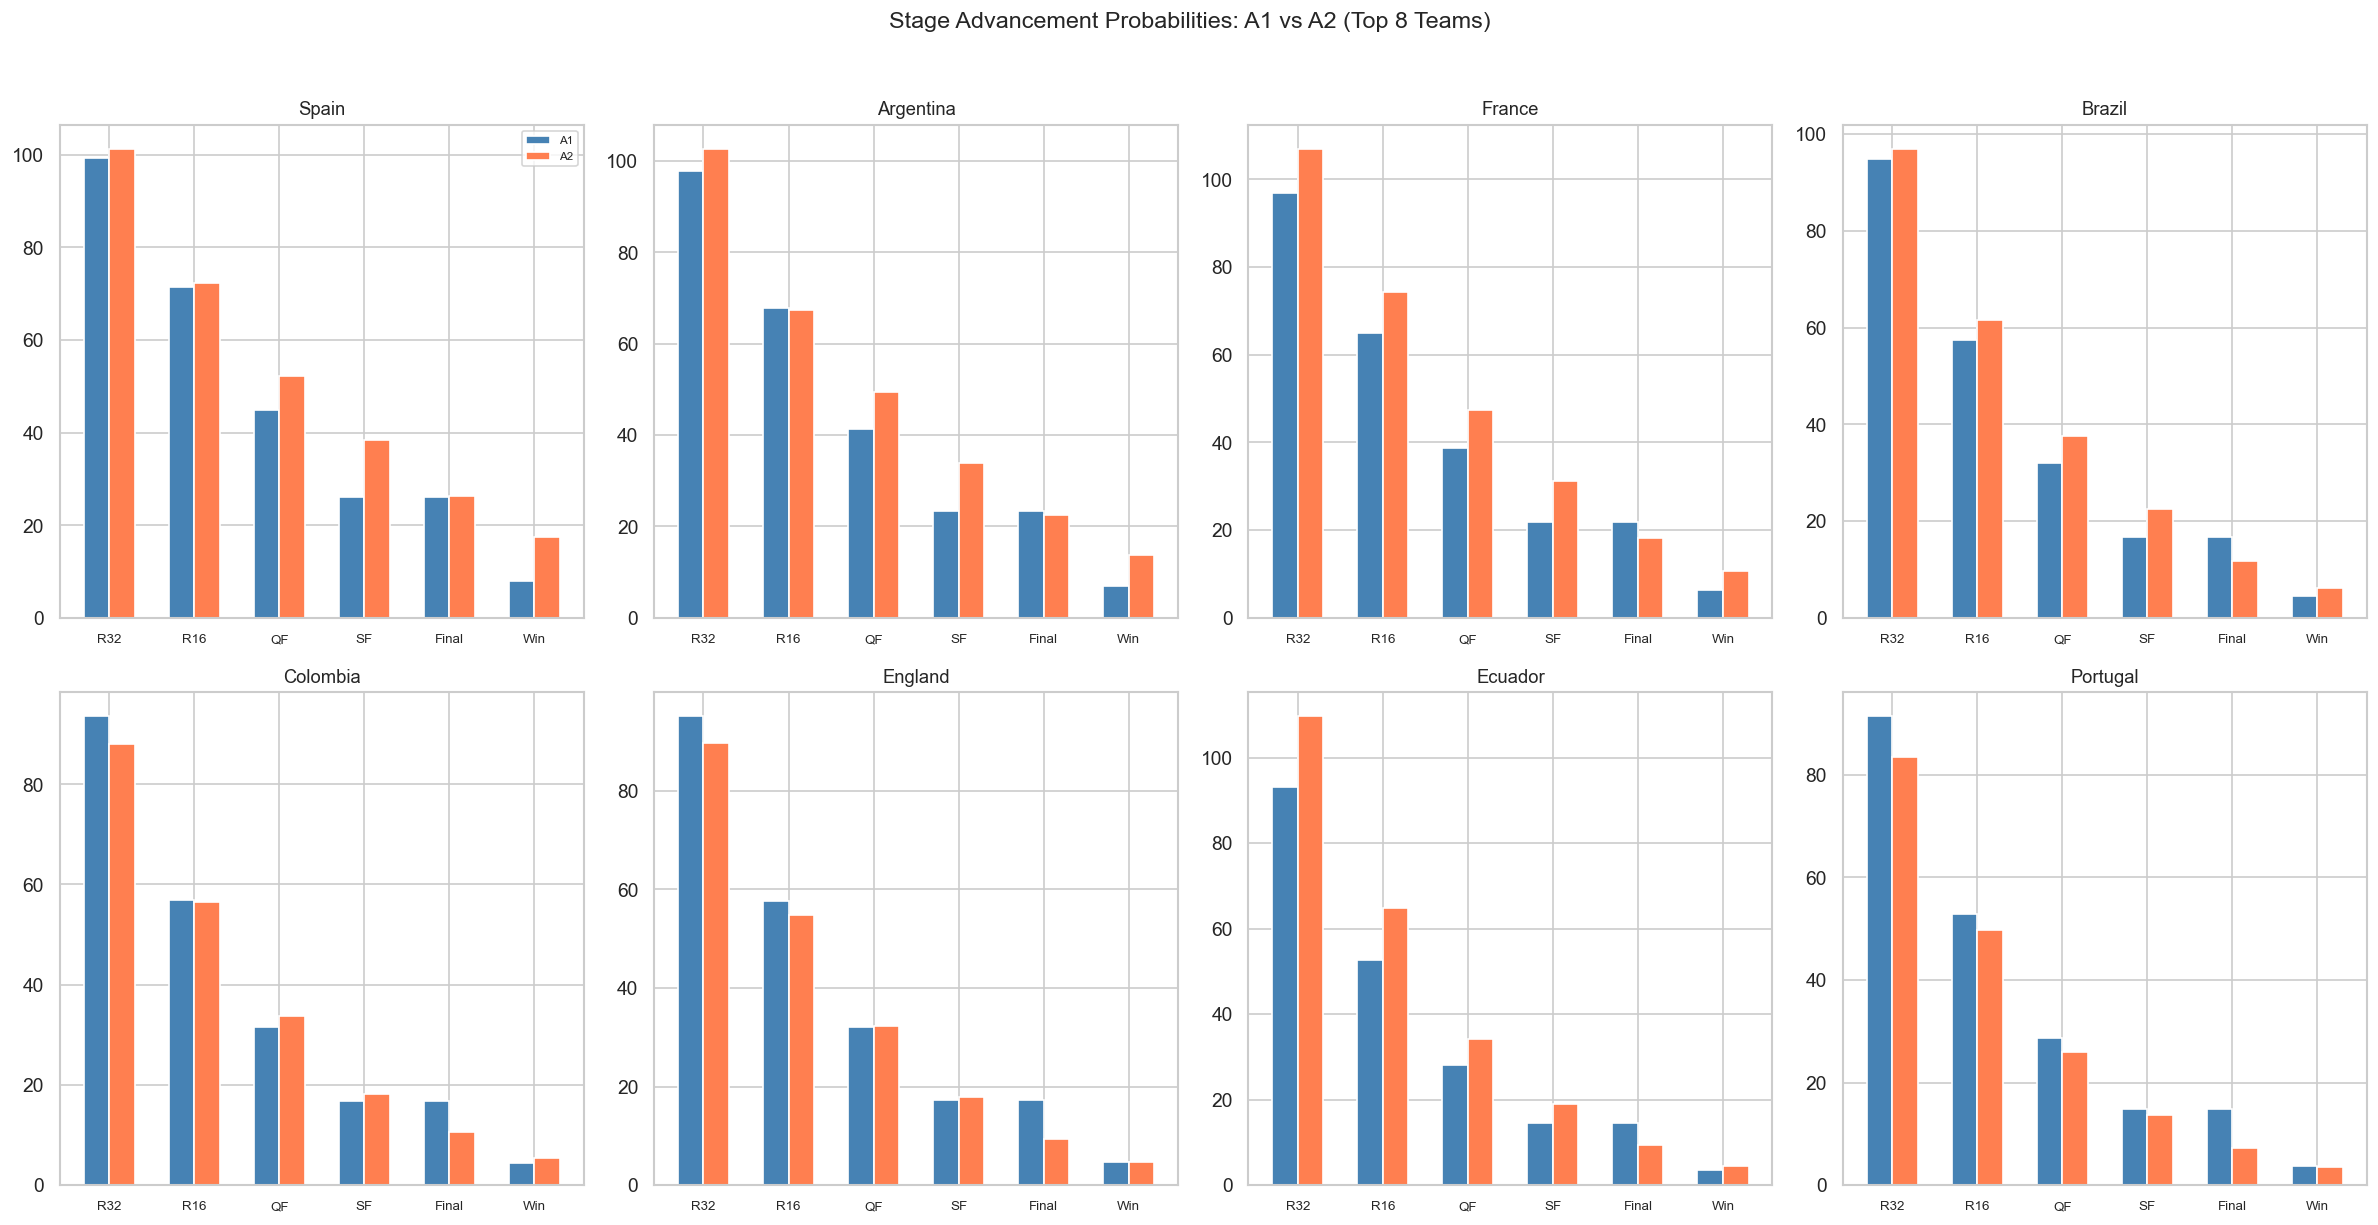

In [15]:
top8 = comparison.nlargest(8, 'A2_Winner').index

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
stage_labels = ['R32', 'R16', 'QF', 'SF', 'Final', 'Win']

for i, (team, ax) in enumerate(zip(top8, axes.flatten())):
    a1_probs = [a1.loc[team, f'{s}_Prob']*100 for s in ['R32','R16','QF','SF','Final','Winner']]
    a2_probs = [a2.loc[team, f'{s}_Prob']*100 for s in ['R32','R16','QF','SF','Final','Winner']]
    
    x = np.arange(len(stage_labels))
    w = 0.3
    ax.bar(x - w/2, a1_probs, w, label='A1', color='steelblue', edgecolor='white')
    ax.bar(x + w/2, a2_probs, w, label='A2', color='coral', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(stage_labels, fontsize=8)
    ax.set_title(team, fontsize=11)
    if i == 0: ax.legend(fontsize=7)

fig.suptitle('Stage Advancement Probabilities: A1 vs A2 (Top 8 Teams)', fontsize=14, y=1.02)
plt.tight_layout()


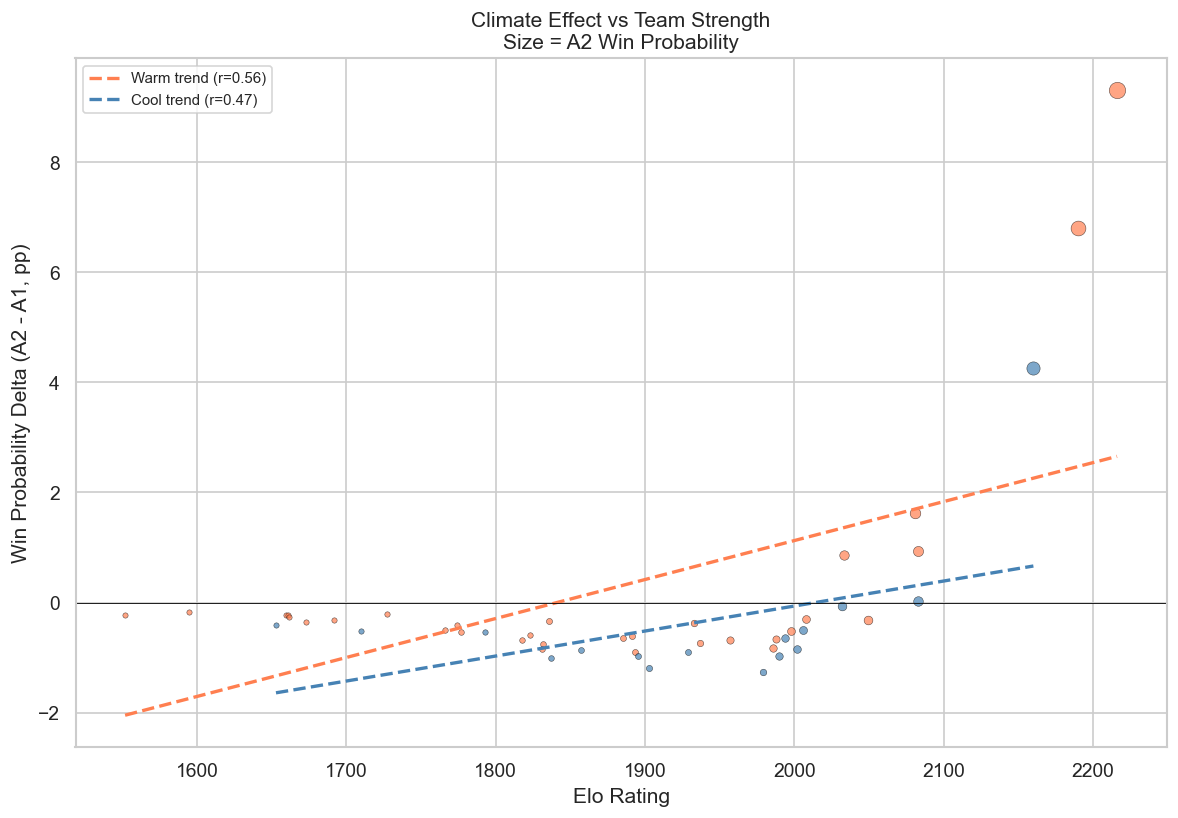

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))

for team in comparison.index:
    w = comparison.loc[team, 'Warm'] == 'WARM'
    c = 'coral' if w else 'steelblue'
    s = comparison.loc[team, 'A2_Winner'] * 5 + 10
    ax.scatter(comparison.loc[team, 'Elo'], comparison.loc[team, 'Winner_Delta'],
               c=c, s=s, alpha=0.7, edgecolors='black', linewidth=0.3)

# Trend lines
warm_mask = comparison['Warm'] == 'WARM'
cool_mask = comparison['Warm'] == 'COOL'
for mask, color, label in [(warm_mask, 'coral', 'Warm'), (cool_mask, 'steelblue', 'Cool')]:
    if mask.sum() > 2:
        z = np.polyfit(comparison.loc[mask, 'Elo'], comparison.loc[mask, 'Winner_Delta'], 1)
        p = np.poly1d(z)
        x_vals = np.linspace(comparison.loc[mask, 'Elo'].min(), comparison.loc[mask, 'Elo'].max(), 50)
        ax.plot(x_vals, p(x_vals), color=color, linestyle='--', linewidth=2, label=f'{label} trend (r={np.corrcoef(comparison.loc[mask, "Elo"], comparison.loc[mask, "Winner_Delta"])[0,1]:.2f})')

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Elo Rating')
ax.set_ylabel('Win Probability Delta (A2 - A1, pp)')
ax.set_title('Climate Effect vs Team Strength\nSize = A2 Win Probability')
ax.legend(fontsize=9)
plt.tight_layout()


/var/folders/3q/6vv9yjp50959b52fy8pc_w6m0000gn/T/ipykernel_81604/2426113497.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Climate', y='Delta (pp)', ax=axes[1],


Warm mean: +0.2 pp, Cool mean: -0.4 pp
Mann-Whitney U: U=362, p=0.0204


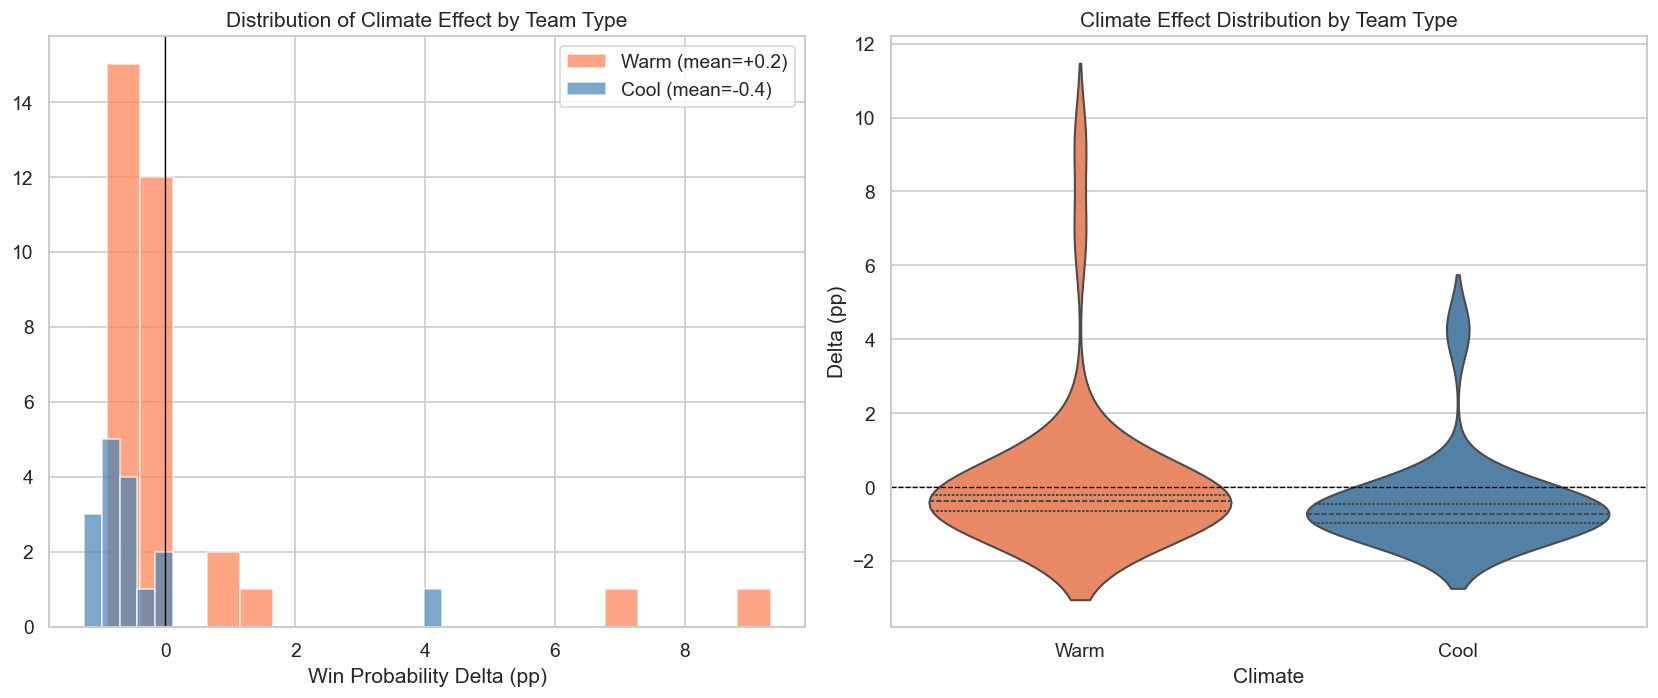

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

warm_deltas = comparison[comparison['Warm'] == 'WARM']['Winner_Delta']
cool_deltas = comparison[comparison['Warm'] == 'COOL']['Winner_Delta']

axes[0].hist(warm_deltas, bins=20, alpha=0.7, color='coral', edgecolor='white', label=f'Warm (mean={warm_deltas.mean():+.1f})')
axes[0].hist(cool_deltas, bins=20, alpha=0.7, color='steelblue', edgecolor='white', label=f'Cool (mean={cool_deltas.mean():+.1f})')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('Win Probability Delta (pp)')
axes[0].set_title('Distribution of Climate Effect by Team Type')
axes[0].legend()

# Violin plot alternative
plot_data = pd.DataFrame({
    'Delta (pp)': pd.concat([warm_deltas, cool_deltas]),
    'Climate': ['Warm'] * len(warm_deltas) + ['Cool'] * len(cool_deltas)
})
sns.violinplot(data=plot_data, x='Climate', y='Delta (pp)', ax=axes[1],
               palette={'Warm': 'coral', 'Cool': 'steelblue'}, inner='quartile')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Climate Effect Distribution by Team Type')

plt.tight_layout()

# Mann-Whitney test
from scipy.stats import mannwhitneyu
u, p = mannwhitneyu(warm_deltas, cool_deltas, alternative='two-sided')
print(f'Warm mean: {warm_deltas.mean():+.1f} pp, Cool mean: {cool_deltas.mean():+.1f} pp')
print(f'Mann-Whitney U: U={u:.0f}, p={p:.4f}')


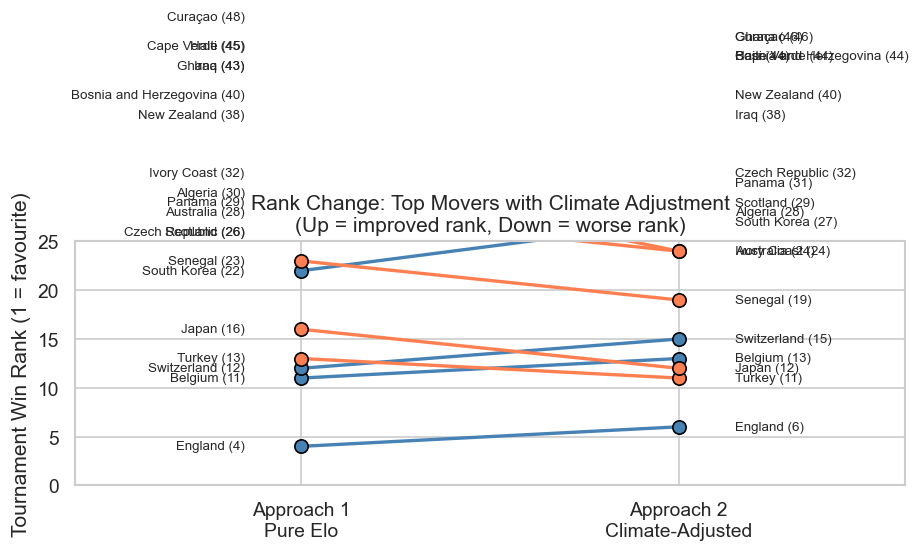

In [18]:
rank_a1 = a1['Winner_Prob'].rank(ascending=False)
rank_a2 = a2['Winner_Prob'].rank(ascending=False)

rank_change = pd.DataFrame({'A1_Rank': rank_a1, 'A2_Rank': rank_a2})
rank_change['Delta'] = rank_change['A1_Rank'] - rank_change['A2_Rank']
rank_change = rank_change.sort_values('Delta', ascending=False)

top_movers = rank_change.nlargest(10, 'Delta').index.union(rank_change.nsmallest(10, 'Delta').index)

fig, ax = plt.subplots(figsize=(8, 10))
for team in sorted(top_movers, key=lambda t: rank_change.loc[t, 'A1_Rank']):
    r1 = int(rank_change.loc[team, 'A1_Rank'])
    r2 = int(rank_change.loc[team, 'A2_Rank'])
    d = r1 - r2
    color = 'coral' if d > 0 else ('steelblue' if d < 0 else 'gray')
    ax.plot([0, 1], [r1, r2], 'o-', color=color, linewidth=2, markersize=8,
            markeredgewidth=1, markeredgecolor='black')
    ax.text(-0.15, r1, f'{team} ({r1})', ha='right', va='center', fontsize=8)
    ax.text(1.15, r2, f'{team} ({r2})', ha='left', va='center', fontsize=8)

ax.set_xlim(-0.6, 1.6)
ax.set_ylim(25, 0)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Approach 1\nPure Elo', 'Approach 2\nClimate-Adjusted'])
ax.set_ylabel('Tournament Win Rank (1 = favourite)')
ax.set_title('Rank Change: Top Movers with Climate Adjustment\n(Up = improved rank, Down = worse rank)')
ax.invert_yaxis()
plt.tight_layout()


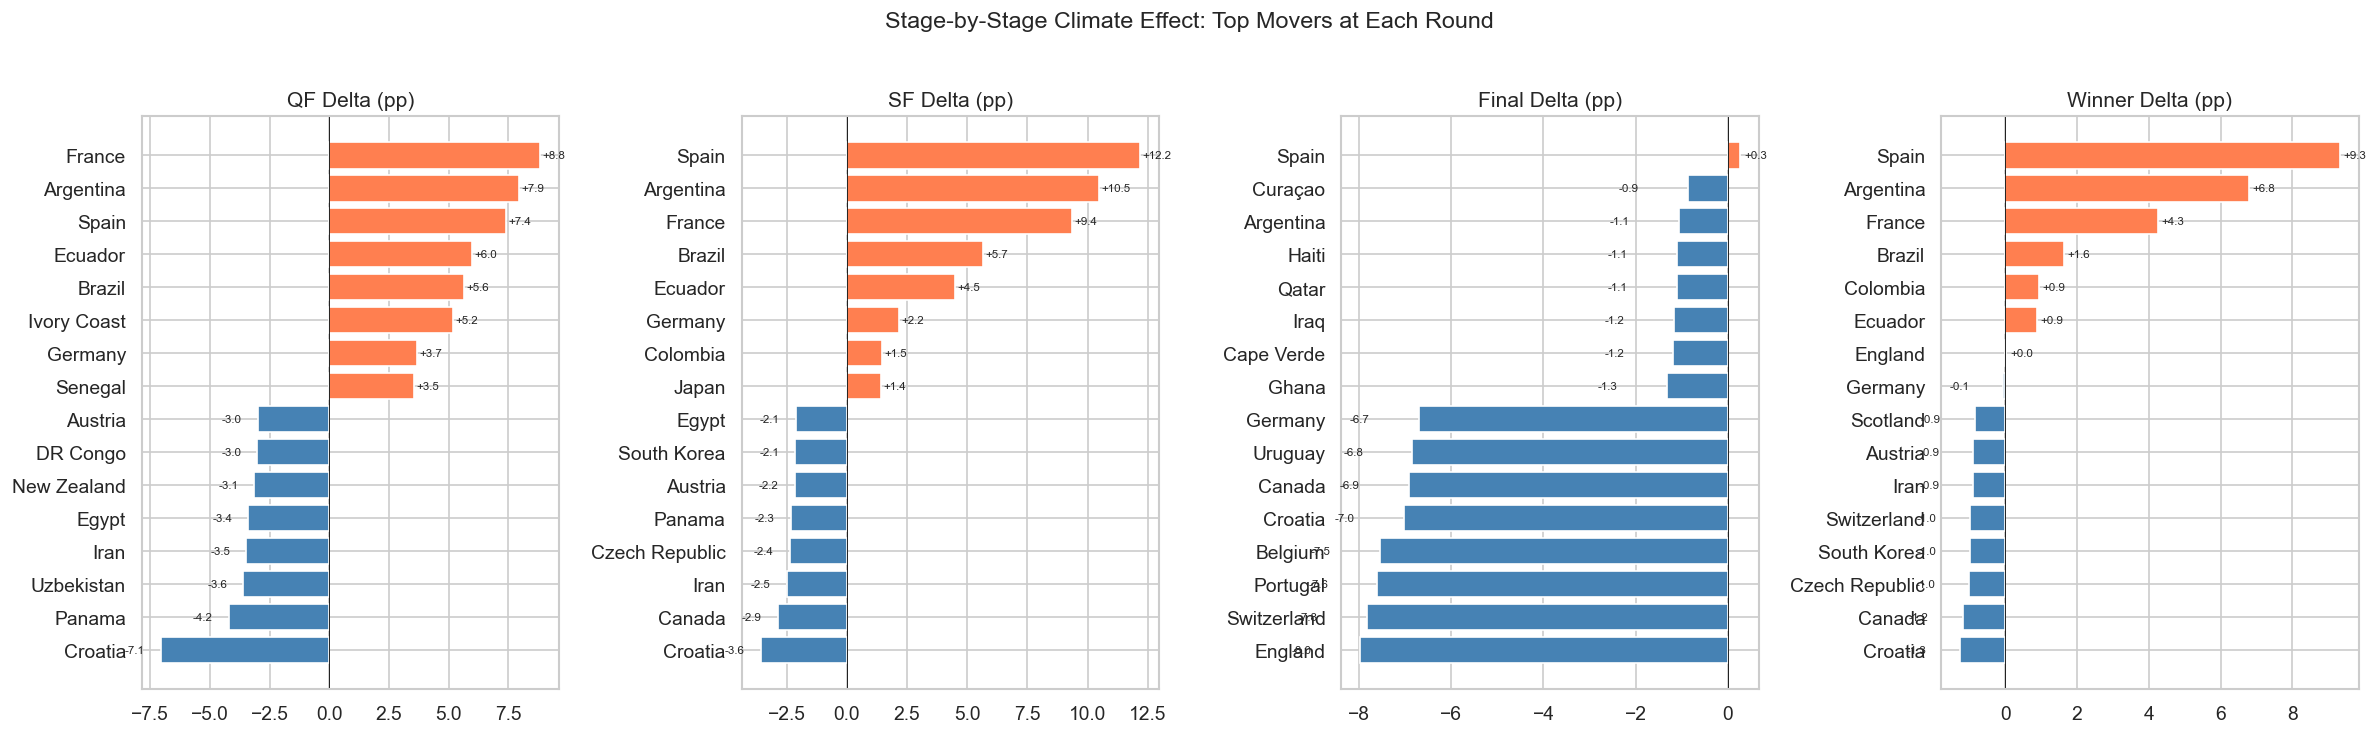

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=False)

for ax, stage in zip(axes, ['QF', 'SF', 'Final', 'Winner']):
    data = comparison.nlargest(8, f'{stage}_Delta').index.union(comparison.nsmallest(8, f'{stage}_Delta').index)
    plot = comparison.loc[sorted(set(data)), f'{stage}_Delta'].sort_values()
    colors = ['coral' if v > 0 else 'steelblue' for v in plot]
    ax.barh(plot.index, plot.values, color=colors, edgecolor='white')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_title(f'{stage} Delta (pp)')
    for i, v in enumerate(plot.values):
        ax.text(v + (0.1 if v >= 0 else -1.5), i, f'{v:+.1f}', va='center', fontsize=7)

fig.suptitle('Stage-by-Stage Climate Effect: Top Movers at Each Round', fontsize=14, y=1.02)
plt.tight_layout()


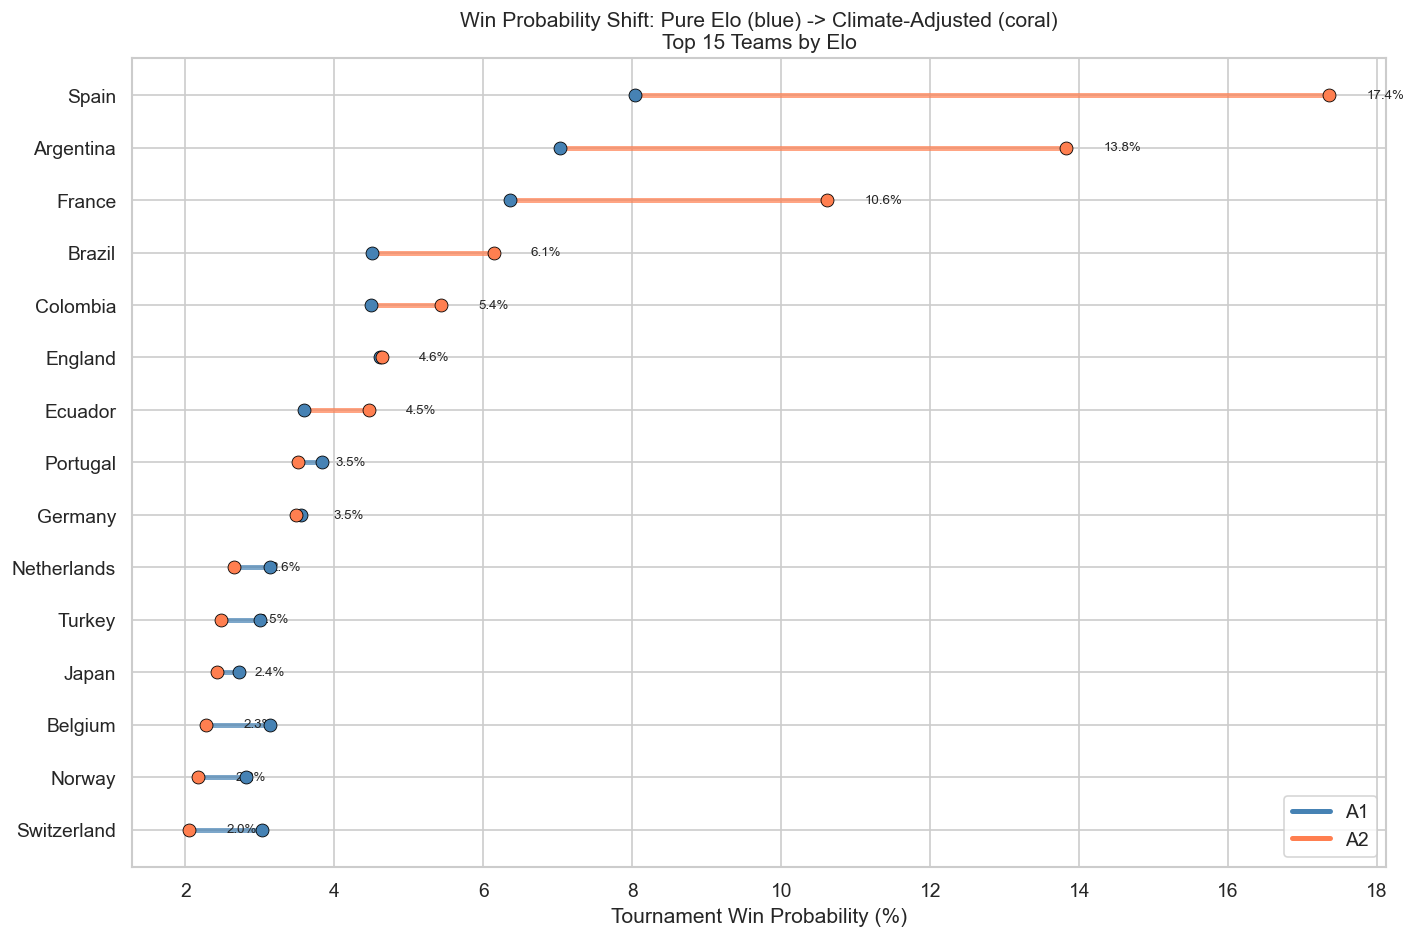

In [20]:
top15 = comparison.nlargest(15, 'Elo').sort_values('A2_Winner')

fig, ax = plt.subplots(figsize=(12, 8))

# Show A1 to A2 as arrows
for i, (team, row) in enumerate(top15.iterrows()):
    a1_p = row['A1_Winner']
    a2_p = row['A2_Winner']
    color = 'coral' if a2_p > a1_p else 'steelblue'
    ax.plot([a1_p, a2_p], [i, i], color=color, linewidth=3, alpha=0.7, solid_capstyle='butt')
    ax.scatter([a1_p], [i], color='steelblue', s=60, zorder=5, edgecolors='black', linewidth=0.5)
    ax.scatter([a2_p], [i], color='coral', s=60, zorder=5, edgecolors='black', linewidth=0.5)
    ax.text(a2_p + 0.5, i, f'{a2_p:.1f}%', va='center', fontsize=8)

ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index)
ax.set_xlabel('Tournament Win Probability (%)')
ax.set_title('Win Probability Shift: Pure Elo (blue) -> Climate-Adjusted (coral)\nTop 15 Teams by Elo')
ax.legend(handles=[plt.Line2D([0],[0],color='steelblue',lw=3,label='A1'),
                   plt.Line2D([0],[0],color='coral',lw=3,label='A2')], loc='lower right')
plt.tight_layout()


---

## Section 6c: Projected Brackets & Tournament Performance


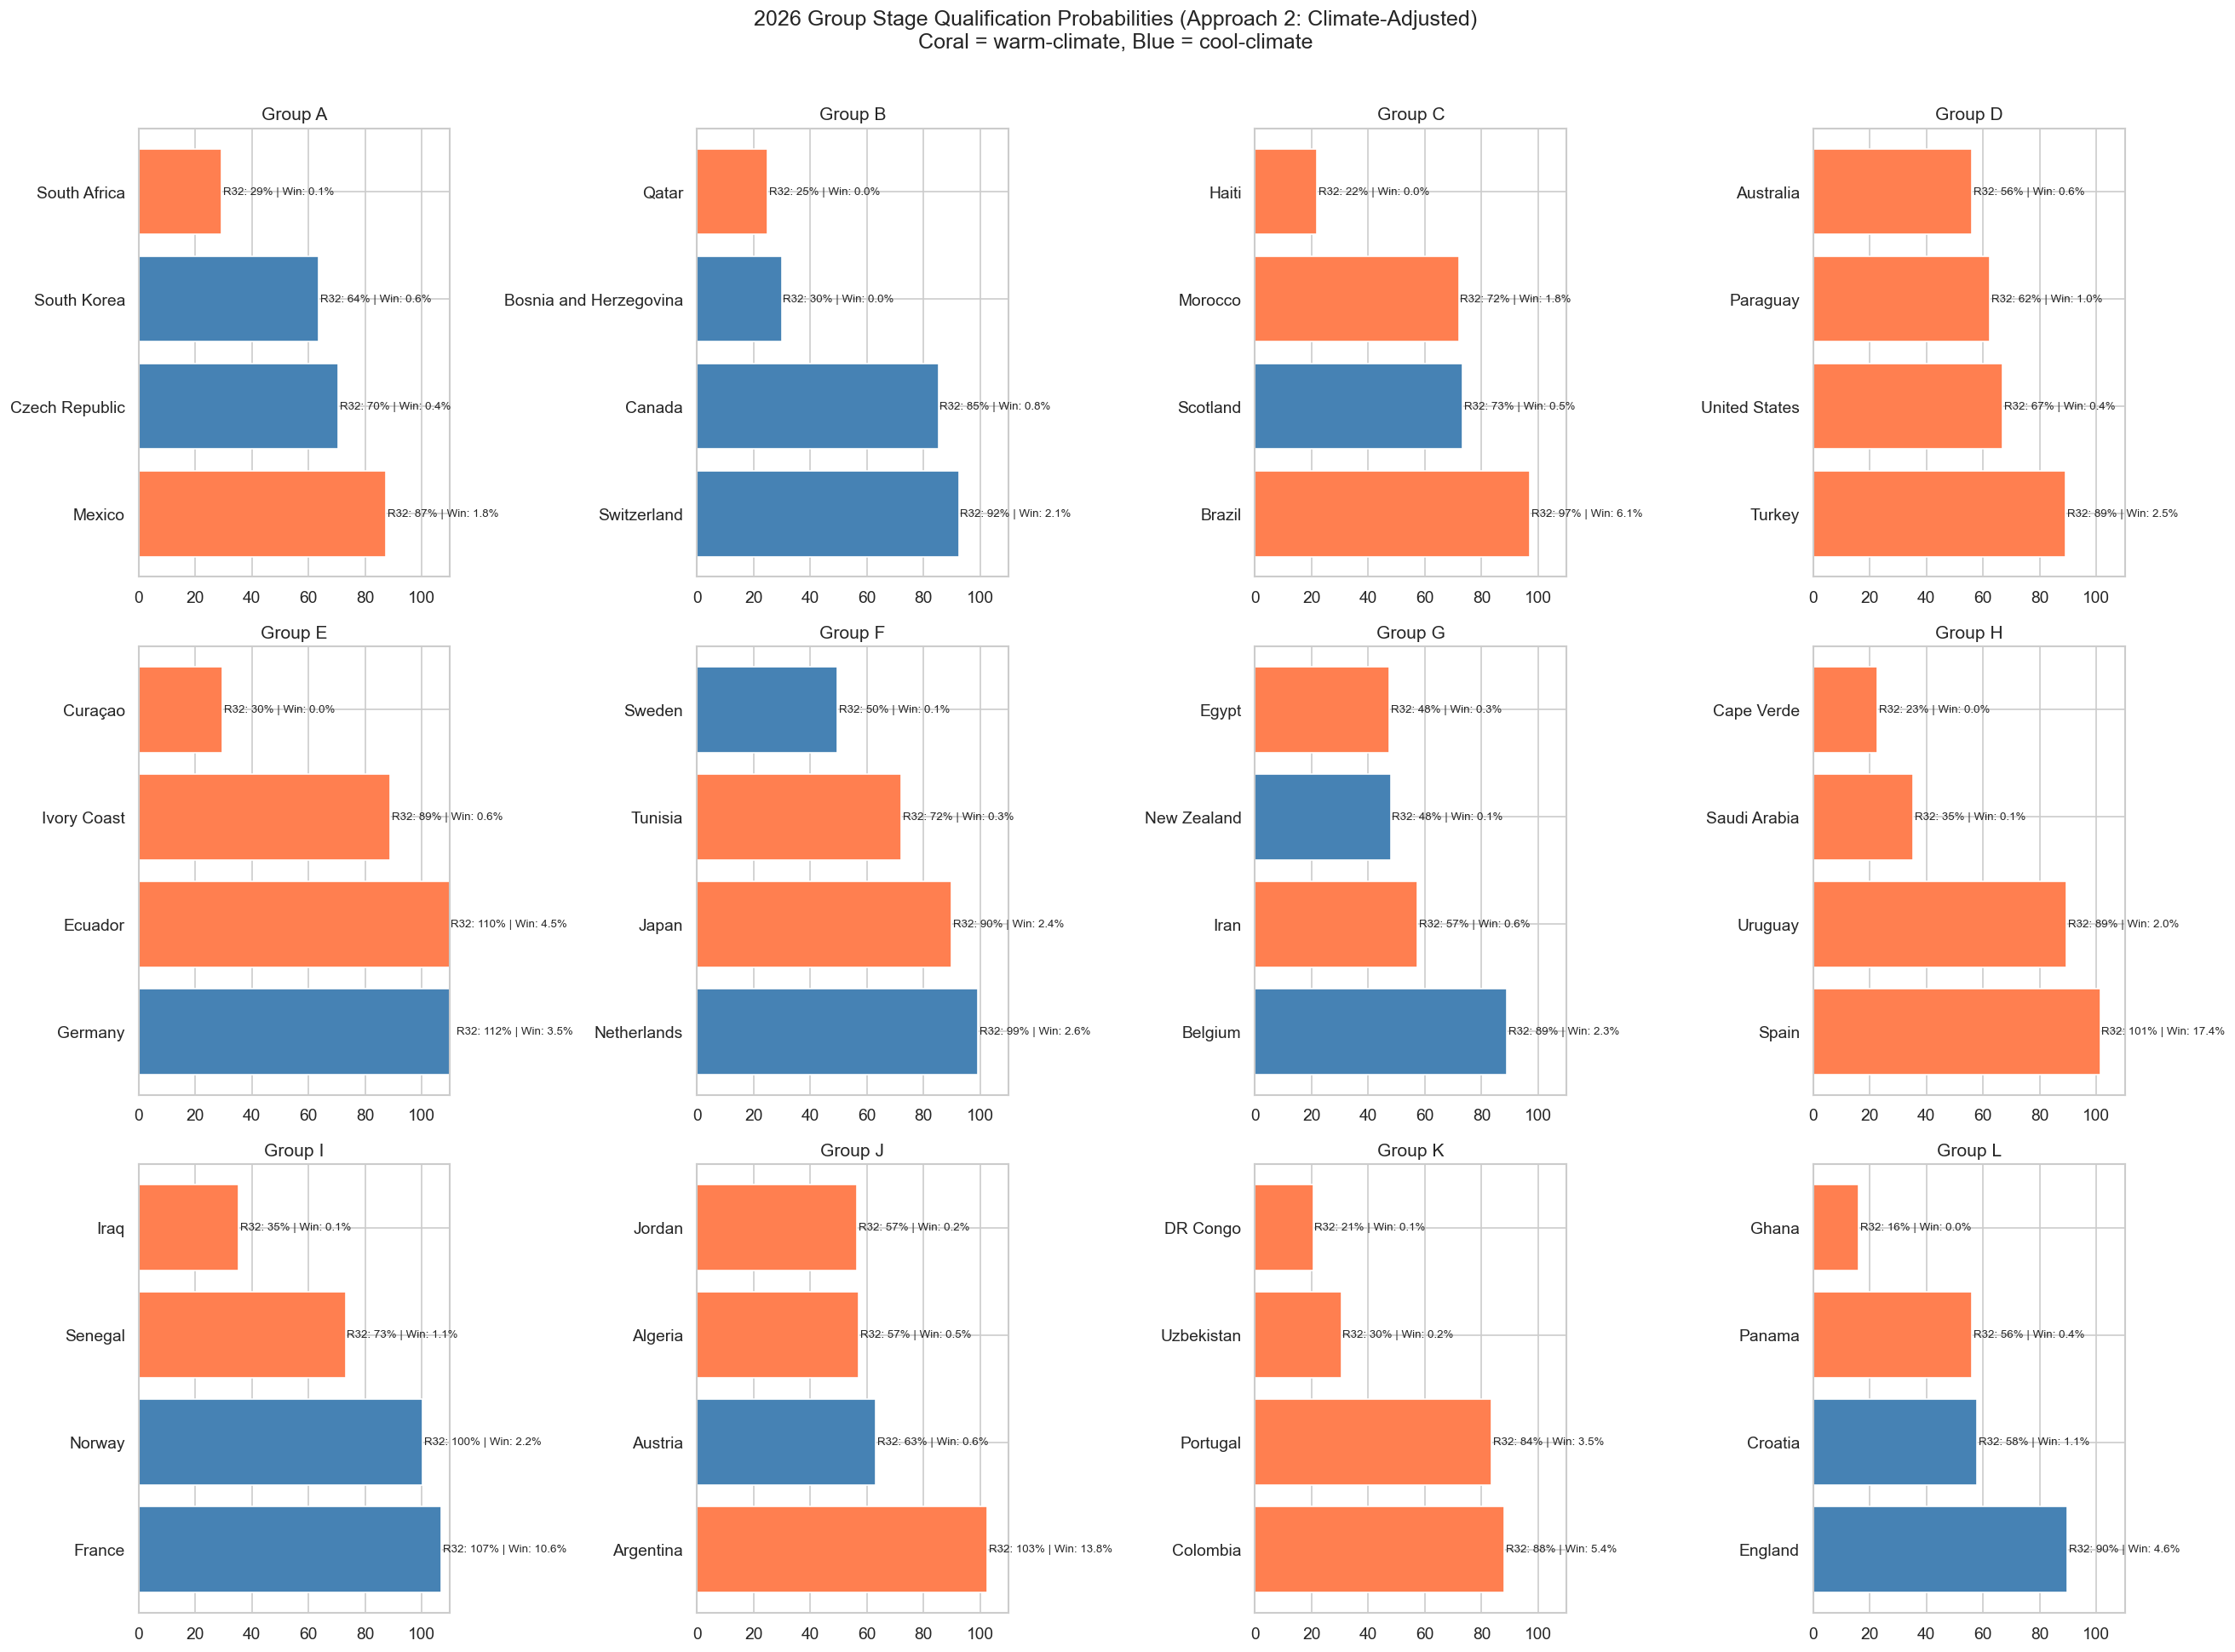

In [21]:
fixtures = pd.read_csv('../data/2026_group_stage.csv')

# Build group-team mapping
team_to_group = {}
for _, row in fixtures.iterrows():
    team_to_group[row['Home_Team']] = row['Group']
    team_to_group[row['Away_Team']] = row['Group']

# From A2 knockout qualification rates (R32_Prob = advancing from group)
group_qual = a2[['R32_Prob']].copy()
group_qual['Group'] = group_qual.index.map(team_to_group)
group_qual['Win_Prob'] = a2['Winner_Prob'] * 100

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
axes = axes.flatten()

for ax, grp in zip(axes, sorted(group_qual['Group'].unique())):
    grp_data = group_qual[group_qual['Group'] == grp].sort_values('R32_Prob', ascending=False)
    colors_grp = ['coral' if warm_map.get(t, 0) else 'steelblue' for t in grp_data.index]
    ax.barh(grp_data.index, grp_data['R32_Prob'] * 100, color=colors_grp, edgecolor='white')
    
    for i, (team, row) in enumerate(grp_data.iterrows()):
        win = row['Win_Prob']
        ax.text(row['R32_Prob'] * 100 + 0.5, i, f'R32: {row["R32_Prob"]*100:.0f}% | Win: {win:.1f}%',
                va='center', fontsize=8)
    
    ax.set_title(f'Group {grp}')
    ax.set_xlim(0, 110)

fig.suptitle('2026 Group Stage Qualification Probabilities (Approach 2: Climate-Adjusted)\n'
             'Coral = warm-climate, Blue = cool-climate', fontsize=15, y=1.01)
plt.tight_layout()


In [22]:
print('PROJECTED KNOCKOUT BRACKET (Approach 2: Climate-Adjusted)')
print('Most likely team at each bracket node, 100,000 simulations')
print('=' * 80)
print()

# R32 projected pairings with probabilities
R32_SLOTS = [
    ('RU A', 'RU B'), ('W E', '3rd A/B/C/D/F'), ('W F', 'RU C'), ('W C', 'RU F'),
    ('W I', '3rd C/D/F/G/H'), ('RU E', 'RU I'), ('W A', '3rd C/E/F/H/I'), ('W L', '3rd E/H/I/J/K'),
    ('W D', '3rd B/E/F/I/J'), ('W G', '3rd A/E/H/I/J'), ('RU K', 'RU L'), ('W H', 'RU J'),
    ('W B', '3rd E/F/G/I/J'), ('W J', 'RU H'), ('W K', '3rd D/E/I/J/L'), ('RU D', 'RU G'),
]

for i, (s1, s2) in enumerate(R32_SLOTS):
    # Find most likely team for each slot based on advancement prob
    print(f'  R32-{i+1:2}: {s1:<22} vs {s2:<22}')

print()

# Projected Final Four
print('PROJECTED FINAL FOUR (by win probability):')
final_four = a2.nlargest(4, 'Winner_Prob')
for i, (t, row) in enumerate(final_four.iterrows()):
    wc = 'WARM' if warm_map.get(t, 0) else 'COOL'
    print(f'  {i+1}. {t:<22} {row["Winner_Prob"]*100:.1f}% [{wc}]')

print()
print('PROJECTED CHAMPION:')
champ = a2.nlargest(1, 'Winner_Prob').index[0]
print(f'  {champ}: {a2.loc[champ, "Winner_Prob"]*100:.1f}%')


PROJECTED KNOCKOUT BRACKET (Approach 2: Climate-Adjusted)
Most likely team at each bracket node, 100,000 simulations

  R32- 1: RU A                   vs RU B                  
  R32- 2: W E                    vs 3rd A/B/C/D/F         
  R32- 3: W F                    vs RU C                  
  R32- 4: W C                    vs RU F                  
  R32- 5: W I                    vs 3rd C/D/F/G/H         
  R32- 6: RU E                   vs RU I                  
  R32- 7: W A                    vs 3rd C/E/F/H/I         
  R32- 8: W L                    vs 3rd E/H/I/J/K         
  R32- 9: W D                    vs 3rd B/E/F/I/J         
  R32-10: W G                    vs 3rd A/E/H/I/J         
  R32-11: RU K                   vs RU L                  
  R32-12: W H                    vs RU J                  
  R32-13: W B                    vs 3rd E/F/G/I/J         
  R32-14: W J                    vs RU H                  
  R32-15: W K                    vs 3rd D/E/I/J/L       

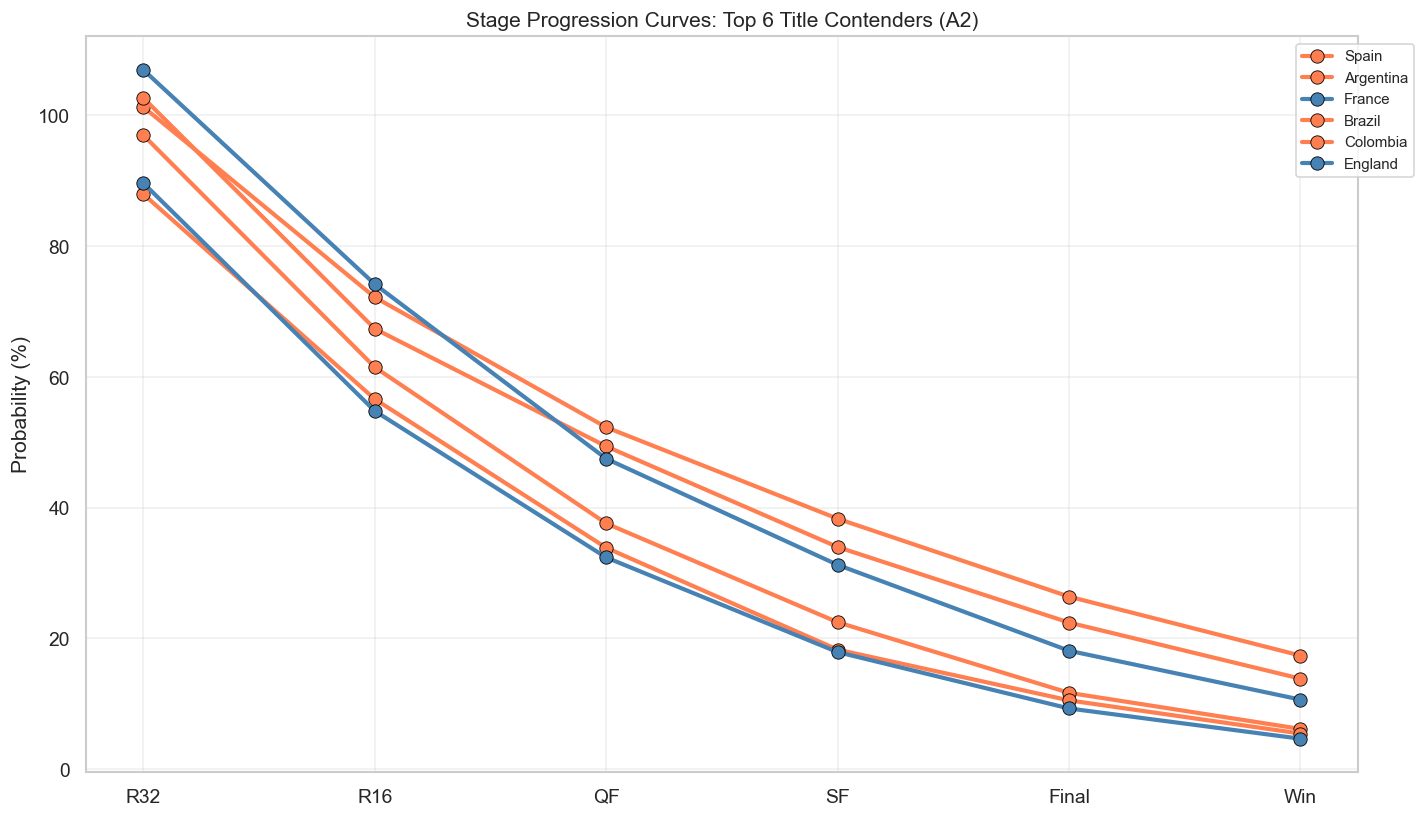

In [23]:
top6 = a2.nlargest(6, 'Winner_Prob').index

fig, ax = plt.subplots(figsize=(12, 7))

for team in top6:
    probs = [a2.loc[team, f'{s}_Prob']*100 for s in ['R32','R16','QF','SF','Final','Winner']]
    color = 'coral' if warm_map.get(team, 0) else 'steelblue'
    ax.plot(['R32','R16','QF','SF','Final','Win'], probs, 'o-', color=color,
            linewidth=2.5, markersize=8, label=team, markeredgecolor='black', markeredgewidth=0.5)

ax.set_ylabel('Probability (%)')
ax.set_title('Stage Progression Curves: Top 6 Title Contenders (A2)')
ax.legend(bbox_to_anchor=(1.05, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()


In [24]:
# Championship matchup probabilities from A2
# Top half (M101) vs Bottom half (M102)
top_half_teams = {t for t in a2.index if team_to_group.get(t, 'Z') in 'ABCDEF'}
bottom_half_teams = {t for t in a2.index if team_to_group.get(t, 'Z') in 'GHIJKL'}

print('MOST LIKELY CHAMPIONSHIP MATCHUPS')
print('(Top half (M101) winner vs Bottom half (M102) winner)')
print('=' * 65)

final_matchups = []
for t1 in a2.nlargest(8, 'Final_Prob').index:
    for t2 in a2.nlargest(8, 'Final_Prob').index:
        if t1 >= t2: continue
        if (t1 in top_half_teams and t2 in bottom_half_teams) or (t2 in top_half_teams and t1 in bottom_half_teams):
            p_joint = a2.loc[t1, 'Final_Prob'] * a2.loc[t2, 'Final_Prob']
            final_matchups.append({'Team_A': t1, 'Team_B': t2, 'Joint_Prob': p_joint})

final_df = pd.DataFrame(final_matchups).sort_values('Joint_Prob', ascending=False).head(10)
for i, (_, r) in enumerate(final_df.iterrows()):
    print(f'  {i+1:2}. {r["Team_A"]:<22} vs {r["Team_B"]:<22}  {r["Joint_Prob"]*100:5.1f}%')

print()
print('Note: Joint probability = P(team A reaches final) * P(team B reaches final)')
print('These are independent approximations; actual conditional probabilities may differ.')


MOST LIKELY CHAMPIONSHIP MATCHUPS
(Top half (M101) winner vs Bottom half (M102) winner)
   1. Brazil                 vs Spain                     3.1%
   2. Argentina              vs Brazil                    2.6%
   3. Ecuador                vs Spain                     2.4%
   4. Brazil                 vs France                    2.1%
   5. Argentina              vs Ecuador                   2.1%
   6. Germany                vs Spain                     2.0%
   7. Argentina              vs Germany                   1.7%
   8. Ecuador                vs France                    1.7%
   9. France                 vs Germany                   1.4%
  10. Brazil                 vs Colombia                  1.2%

Note: Joint probability = P(team A reaches final) * P(team B reaches final)
These are independent approximations; actual conditional probabilities may differ.


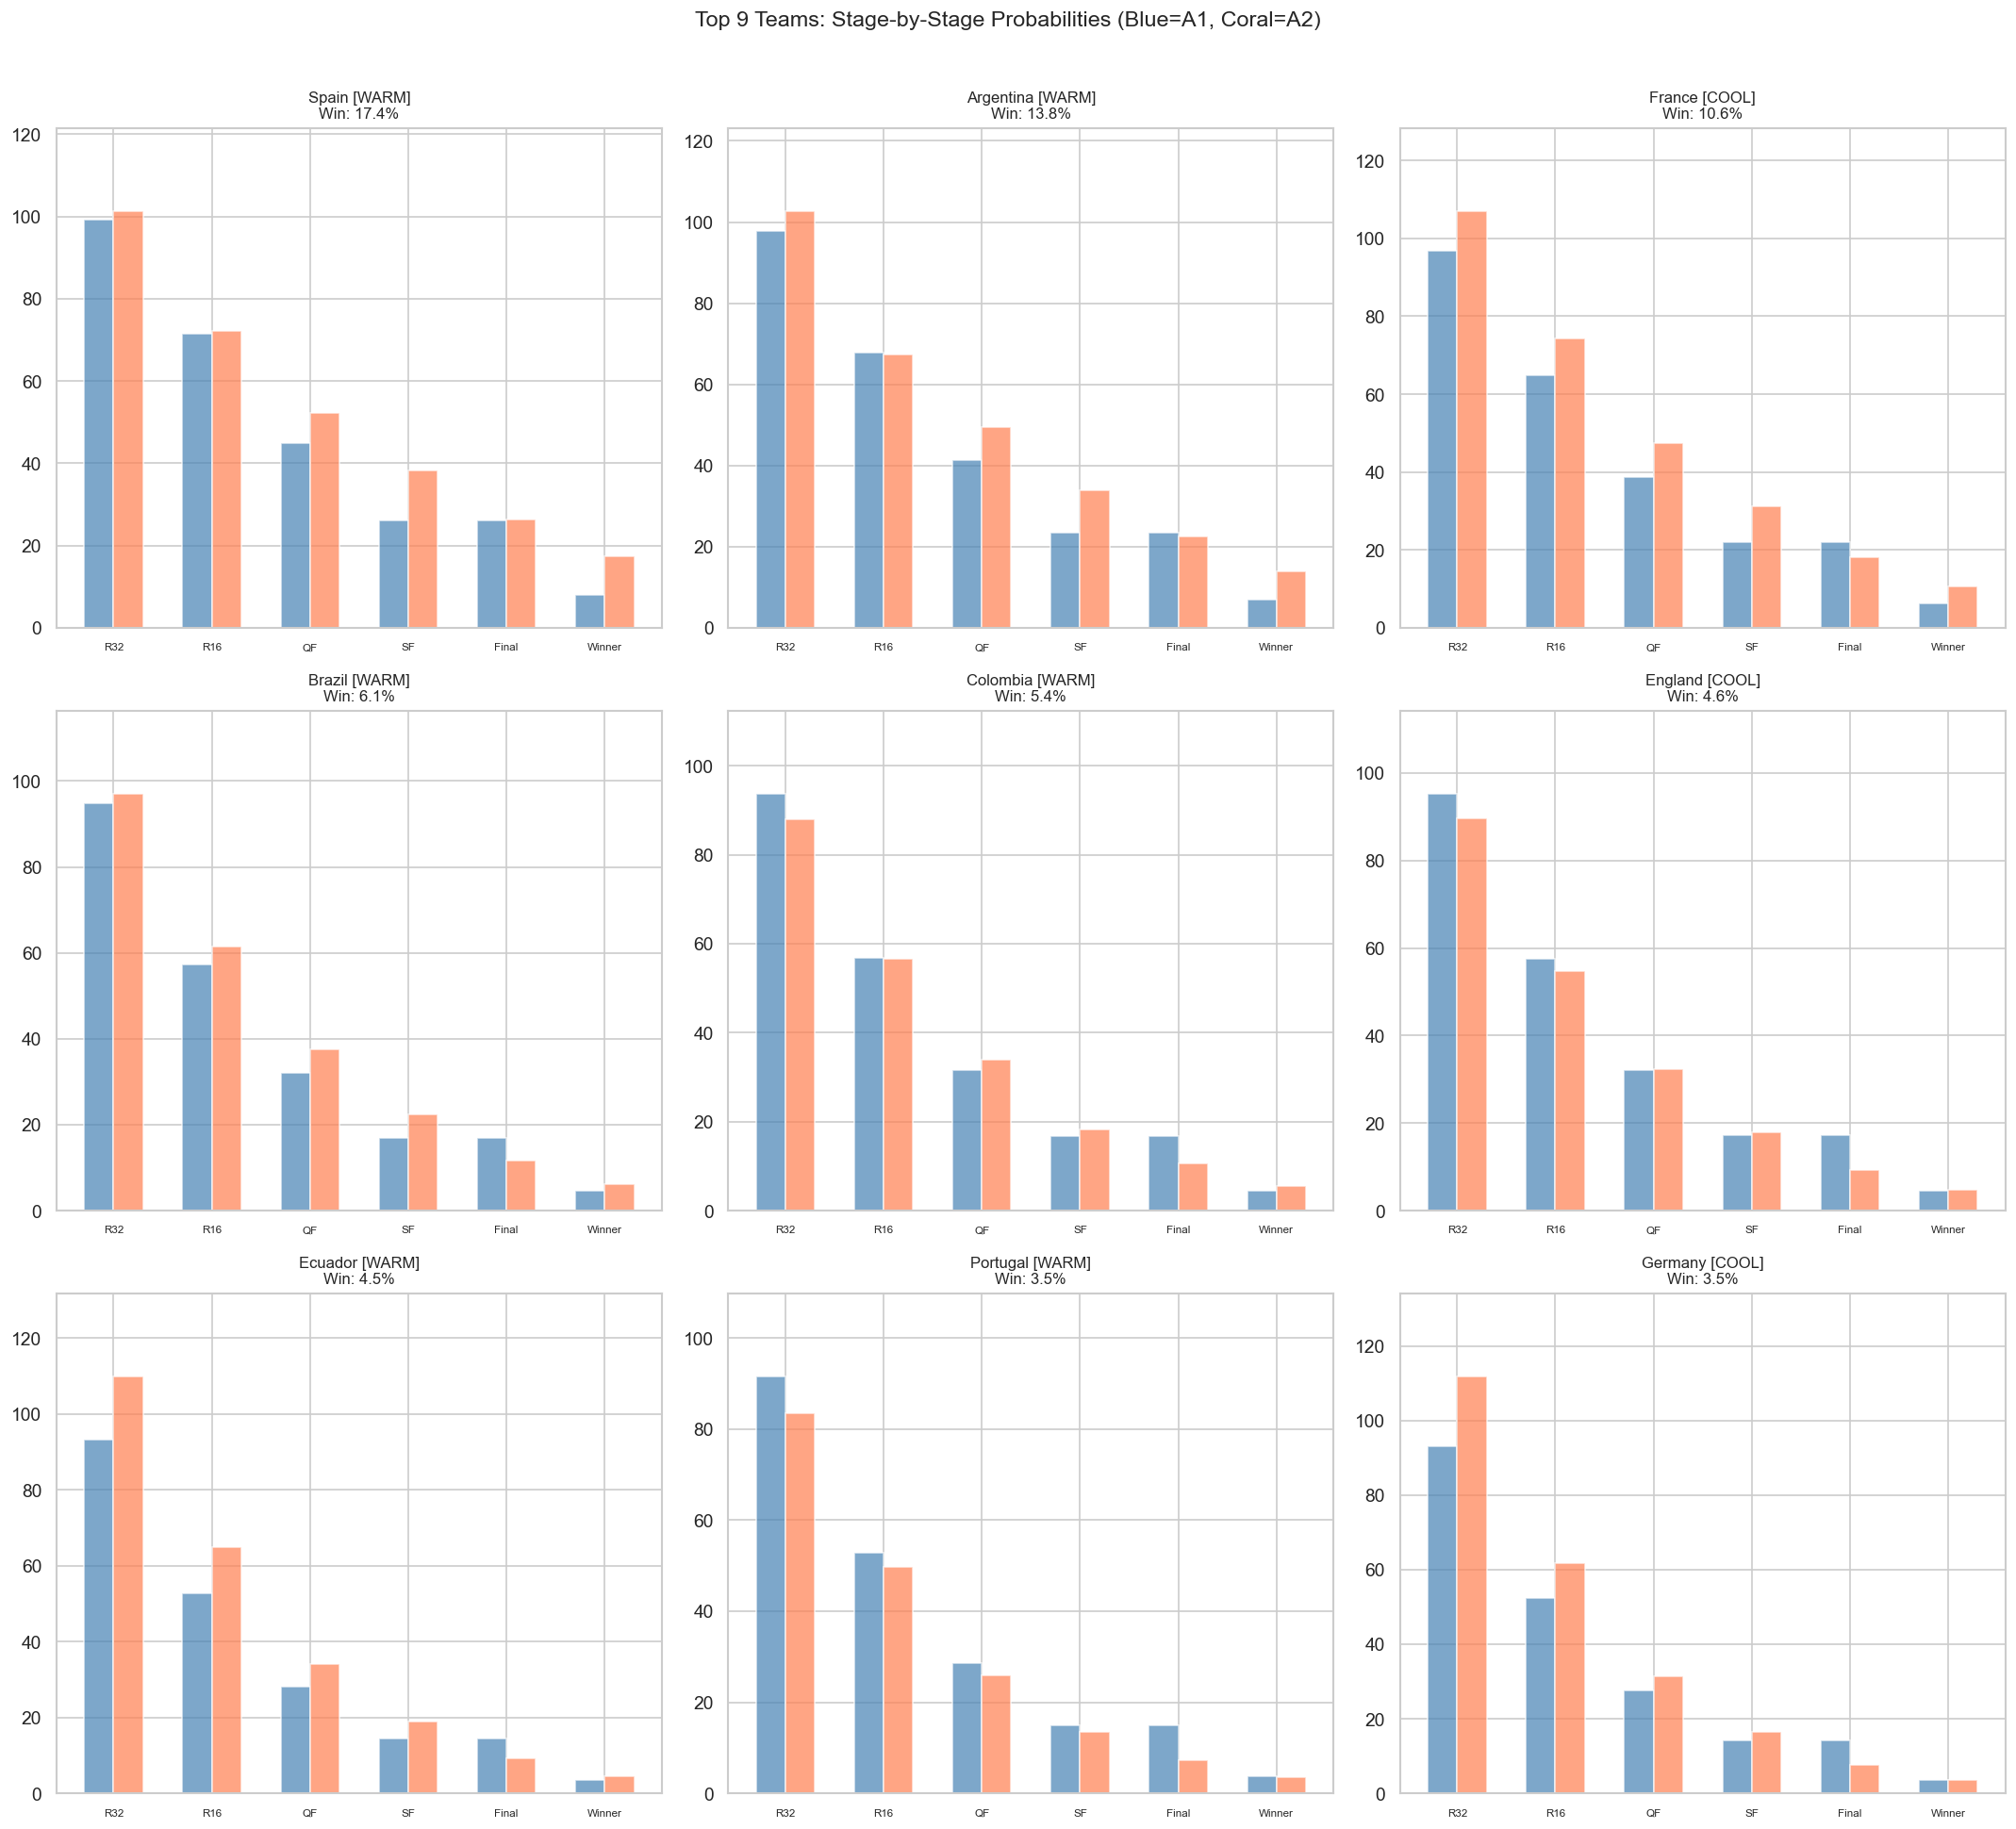

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

top9 = a2.nlargest(9, 'Winner_Prob').index

for i, (team, ax) in enumerate(zip(top9, axes)):
    stages_list = ['R32', 'R16', 'QF', 'SF', 'Final', 'Winner']
    a1_p = [a1.loc[team, f'{s}_Prob']*100 for s in stages_list]
    a2_p = [a2.loc[team, f'{s}_Prob']*100 for s in stages_list]
    
    x = np.arange(len(stages_list))
    w = 0.3
    ax.bar(x - w/2, a1_p, w, color='steelblue', alpha=0.7, edgecolor='white')
    ax.bar(x + w/2, a2_p, w, color='coral', alpha=0.7, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(stages_list, fontsize=7)
    
    wc = 'WARM' if warm_map.get(team, 0) else 'COOL'
    ax.set_title(f'{team} [{wc}]\nWin: {a2_p[-1]:.1f}%', fontsize=10)
    ax.set_ylim(0, max(max(a1_p), max(a2_p)) * 1.2)

fig.suptitle('Top 9 Teams: Stage-by-Stage Probabilities (Blue=A1, Coral=A2)', fontsize=14, y=1.01)
plt.tight_layout()


Percentage of warm teams at each stage:
  R32      61.6% warm, 38.4% cool
  R16      60.8% warm, 39.2% cool
  QF       61.6% warm, 38.4% cool
  SF       63.2% warm, 36.8% cool
  Final    65.8% warm, 34.2% cool
  Winner   67.9% warm, 32.1% cool


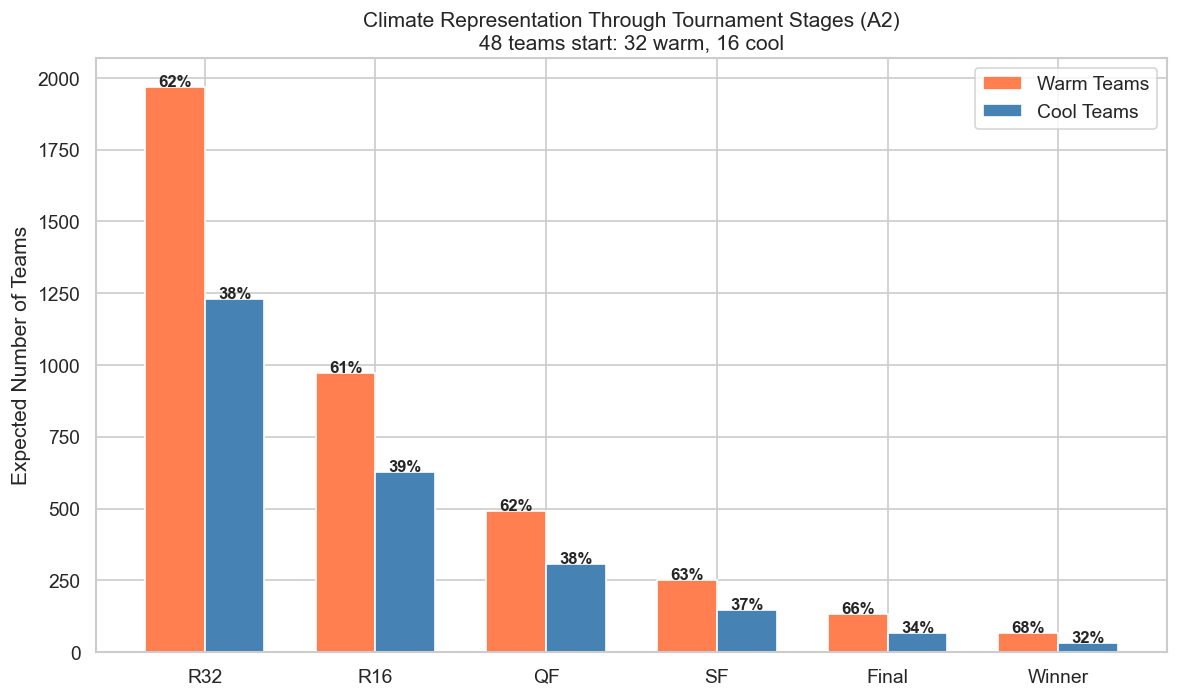

In [26]:
stages = ['R32', 'R16', 'QF', 'SF', 'Final', 'Winner']
warm_expected = []
cool_expected = []

for s in stages:
    warm_count = sum(a2.loc[t, f'{s}_Prob'] * 100 for t in a2.index if warm_map.get(t, 0))
    cool_count = sum(a2.loc[t, f'{s}_Prob'] * 100 for t in a2.index if not warm_map.get(t, 0))
    warm_expected.append(warm_count)
    cool_expected.append(cool_count)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(stages))
w = 0.35

ax.bar(x - w/2, warm_expected, w, label='Warm Teams', color='coral', edgecolor='white')
ax.bar(x + w/2, cool_expected, w, label='Cool Teams', color='steelblue', edgecolor='white')

for i, (we, ce) in enumerate(zip(warm_expected, cool_expected)):
    total = we + ce
    ax.text(i - w/2, we + 2, f'{we/total*100:.0f}%', ha='center', fontsize=10, fontweight='bold')
    ax.text(i + w/2, ce + 2, f'{ce/total*100:.0f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylabel('Expected Number of Teams')
ax.set_title('Climate Representation Through Tournament Stages (A2)\n'
             f'48 teams start: {sum(1 for t in a2.index if warm_map.get(t,0))} warm, {sum(1 for t in a2.index if not warm_map.get(t,0))} cool')
ax.legend()
plt.tight_layout()

print('Percentage of warm teams at each stage:')
for s, we, ce in zip(stages, warm_expected, cool_expected):
    pct = we / (we + ce) * 100
    print(f'  {s:<8} {pct:.1f}% warm, {100-pct:.1f}% cool')
